# Gene2Wire — self-contained SPIDER 0–80% Colab

**Owner:** `yola.liu.life@gmail.com`

Everything specific to SPIDER is implemented directly in this notebook: raw
download/checksum, biological filtering, feature construction, spatial split,
Technical-SAR hiding, paired calibration, evaluation, tables, and plots.

Only the model layer is imported from the core-only GitHub repository. The core
receives processed train/validation labels and outer-test `X`; it never receives
pre-hide test truth or the hidden-positive mask.

The full default run is expensive: 4 folds × 5 rates × 6 models, with 2,040
tuning candidates and 120 final refits. Checkpoints are saved to Drive. After a
runtime disconnect, reconnect and run from the top; completed candidates and
models are restored automatically.


## 1. Settings

In [43]:
from pathlib import Path

REPOSITORY = "Yue-stat/Gene2Wire-core"
CORE_COMMIT = "d2a139bcd411ebbc4a3305a691b497a6642c5391"  # immutable core-only commit

RATES = [0.8]
OUTER_FOLDS = [0, 1, 2, 3]
MODEL_NAMES = ["Logistic", "PU logistic", "MIRT", "PU-MIRT", "Joint", "PU-Joint"]

DRIVE_PROJECT = Path("/content/drive/MyDrive/Gene2Wire")
CACHE_DIR = DRIVE_PROJECT / "data" / "SPIDER"
OUTPUT_DIR = DRIVE_PROJECT / "results" / "SPIDER_Technical_SAR_0_20_40_60_80"
REPO_DIR = Path("/content/Gene2Wire_core")

# Quick debugging only:
# OUTER_FOLDS = [0]
# MODEL_NAMES = ["PU logistic", "PU-MIRT"]


## 2. Mount Drive and install the pinned public core

The model-only repository is public, so this notebook downloads an immutable
commit directly from GitHub. No GitHub token or Colab secret is required.


In [44]:
from google.colab import drive
drive.mount("/content/drive")

import os
import shutil
import subprocess
import sys
import tarfile
import tempfile
from urllib.request import Request, urlopen

DRIVE_PROJECT.mkdir(parents=True, exist_ok=True)

# Dependencies for SPIDER-specific notebook cells. They are intentionally not
# dependencies of the GitHub core package.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "rdata==1.1.0",
        "pandas>=2.0",
        "matplotlib>=3.7",
        "scikit-learn>=1.4",
    ],
    check=True,
)

if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

# Download the exact immutable commit from the public core repository. No
# GitHub token or Colab secret is required.
with tempfile.TemporaryDirectory(prefix="gene2wire_core_") as temporary_directory:
    temporary_path = Path(temporary_directory)
    archive_path = temporary_path / "core.tar.gz"
    extract_path = temporary_path / "extracted"
    extract_path.mkdir()
    archive_url = f"https://github.com/{REPOSITORY}/archive/{CORE_COMMIT}.tar.gz"
    try:
        request = Request(
            archive_url,
            headers={"User-Agent": "Gene2Wire-SPIDER-self-contained-v3"},
        )
        with urlopen(request, timeout=120) as response:
            with archive_path.open("wb") as destination:
                shutil.copyfileobj(response, destination)
    except Exception as exc:
        raise RuntimeError(
            f"Could not download public Gene2Wire core commit {CORE_COMMIT}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    with tarfile.open(archive_path, mode="r:gz") as archive:
        top_directories = {
            member.name.split("/", 1)[0]
            for member in archive.getmembers()
            if member.name and "/" in member.name
        }
        if len(top_directories) != 1:
            raise RuntimeError(f"Unexpected GitHub archive layout: {sorted(top_directories)}")
        try:
            archive.extractall(extract_path, filter="data")
        except TypeError:  # Python < 3.12
            archive.extractall(extract_path)
    shutil.move(str(extract_path / next(iter(top_directories))), str(REPO_DIR))

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)], check=True)

# PEP 660 editable installs use a .pth hook that is normally processed only
# when a new Python interpreter starts. This notebook must import the package
# immediately in the current kernel, so add the actual src-layout directory.
core_source_dir = REPO_DIR / "src"
if str(core_source_dir) not in sys.path:
    sys.path.insert(0, str(core_source_dir))

import importlib
for module_name in list(sys.modules):
    if module_name == "gene2wire" or module_name.startswith("gene2wire."):
        del sys.modules[module_name]
importlib.invalidate_caches()

import gene2wire
assert Path(gene2wire.__file__).resolve().is_relative_to(core_source_dir.resolve())
os.environ["GENE2WIRE_CORE_REF"] = CORE_COMMIT

installed_commit = CORE_COMMIT
assert installed_commit == CORE_COMMIT
assert not (REPO_DIR / "experiments").exists(), "Pinned GitHub commit is not core-only"
core_source = "\n".join(
    path.read_text(encoding="utf-8") for path in (REPO_DIR / "src/gene2wire").glob("*.py")
)
assert "SPIDER" not in core_source
print("Installed core-only Gene2Wire commit:", installed_commit)
print("Imported gene2wire from:", gene2wire.__file__)
print("Persistent output:", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Installed core-only Gene2Wire commit: d2a139bcd411ebbc4a3305a691b497a6642c5391
Imported gene2wire from: /content/Gene2Wire_core/src/gene2wire/__init__.py
Persistent output: /content/drive/MyDrive/Gene2Wire/results/SPIDER_Technical_SAR_0_20_40_60_80


## 3. Model families and hyperparameter grid

In [45]:
from gene2wire import ExperimentConfig, FitConfig, ModelConfig, TuningConfig

experiment = ExperimentConfig(
    version=2,
    dataset={
        "name": "SPIDER",
        "raw_rds_sha256": "9069585cadd37b22edb236a5c0fb84c1326a0a9be1f9bc67f4068a8295d45cae",
        "notebook_pipeline": "self-contained-colab-2026-09-03-v3",
    },
    split={
        "outer": "spatial_ap_contiguous_4fold",
        "inner": "four_spaced_spatial_slices",
        "preprocessing_fit": "inner_train_only",
    },
    observation={
        "family": "technical_sar",
        "technical_sar_rates": RATES,
        "maximum_rate": 0.8,
        "paired_calibration_fraction": 0.20,
        "technical_high_exposure_fraction": 0.20,
        "technical_low_range": [0.02, 0.10],
        "technical_high_range": [0.90, 1.00],
    },
    models=(
        ModelConfig(name="Logistic", kind="direct", pu=False),
        ModelConfig(name="PU logistic", kind="direct", pu=True),
        ModelConfig(name="MIRT", kind="lowrank", rank=4, pu=False),
        ModelConfig(name="PU-MIRT", kind="lowrank", rank=4, pu=True),
        ModelConfig(name="Joint", kind="joint", rank=4, pu=False),
        ModelConfig(name="PU-Joint", kind="joint", rank=4, pu=True),
    ),
    tuning=TuningConfig(
        strategy="full_joint",
        ranks=(2, 4, 8, 12),
        shared_l2=(1e-5, 1e-3, 1e-2),
        residual_l2=(1e-5, 1e-3, 1e-2),
        target_l2=(1e-3,),
        anchor_shared_l2=1e-3,
        anchor_residual_l2=1e-3,
        anchor_target_l2=1e-3,
        metric="observed_log_loss",
    ),
    fit=FitConfig(
        maxiter=500,
        tolerance=1e-8,
        initialization="svd",
        init_direct_maxiter=120,
    ),
    runtime={"base_seed": 20260903},
    evaluation={
        "pre_hide_reference_is_evaluation_only": True,
        "brier_skill_baseline": "inner_train_prevalence",
    },
)

chosen_models = [model for model in experiment.models if model.name in MODEL_NAMES]
assert len(chosen_models) == len(MODEL_NAMES)
print("Models:", MODEL_NAMES)
print("Rates:", [int(rate * 100) for rate in RATES])


Models: ['Logistic', 'PU logistic', 'MIRT', 'PU-MIRT', 'Joint', 'PU-Joint']
Rates: [80]


## 4. SPIDER raw-data loader (defined directly here)

In [46]:
"""End-to-end SPIDER Technical-SAR experiment and plotting pipeline.

This module ports the audited raw-data, spatial-split, semisynthetic hiding,
paired-calibration, evaluation, checkpoint, and plotting steps into the shared
``run_model_grid`` core API.  The biological reference used for evaluation is the
original pre-hide SPIDER detection label; it is not asserted to be perfect
biological ground truth.
"""

from __future__ import annotations

import argparse
from dataclasses import asdict, dataclass, replace
import hashlib
import json
import math
import os
from pathlib import Path
import tempfile
import time
from typing import Any, Iterable, Mapping, Sequence
import urllib.request
import warnings
import zipfile

import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.sparse import csc_matrix
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler

from gene2wire.checkpoint import (
    AtomicCheckpointStore,
    experiment_fingerprint,
    sha256_file,
    sha256_source_tree,
    unit_key,
)
from gene2wire.config import ExperimentConfig, ModelConfig, load_config
from gene2wire.data import DatasetBundle
from gene2wire.runner import CORE_API_VERSION, run_model_grid
from gene2wire.seeds import stable_seed
from gene2wire.tuning import full_joint_candidates


SPIDER_PIPELINE_VERSION = "self-contained-colab-2026-09-03-v3"
SPIDER_RDS_URL = (
    "https://huggingface.co/spaces/TigerZheng/"
    "SPIDER-web/resolve/main/data/sp.PFC.rds?download=true"
)
SPIDER_RDS_SHA256 = "9069585cadd37b22edb236a5c0fb84c1326a0a9be1f9bc67f4068a8295d45cae"
SPIDER_TARGETS = (
    "VIS-I", "ACB-I", "CP-C", "AId-I", "CP-I",
    "ECT-C", "AId-C", "ECT-I", "BLA-I", "AUD-I",
    "RSP-C", "SSp-I", "RSP-I", "ACB-C", "LHA-I",
)
SPIDER_LOCATION_COLUMNS = ("ML_new", "DV_new", "AP_new")
SPIDER_INCLUDED_LAYERS = ("L2/3 IT", "L4/5 IT", "L5 IT", "L6 IT", "L5 PT")

DISCRIMINATION_COLUMNS = ("AUPRC", "AUROC", "Recall@100")
PROBABILITY_COLUMNS = (
    "Latent Brier", "Latent Brier skill", "Latent log loss", "Latent ECE",
    "Predicted latent prevalence", "True pre-hide prevalence",
    "Latent prevalence bias", "Latent prevalence absolute error",
    "Latent prevalence ratio", "Detection Brier", "Detection log loss",
    "Detection ECE",
)
RECOVERY_COLUMNS = (
    "Proxy AUPRC", "Hidden Recall@H", "Enrichment over random",
    "Mean hidden percentile",
)


@dataclass(frozen=True)
class SpiderData:
    """Validated pre-hide SPIDER arrays in the canonical cell order."""

    X_gene_raw: np.ndarray
    X_loc_raw: np.ndarray
    Z_reference: np.ndarray
    W_measured: np.ndarray
    cell_ids: tuple[str, ...]
    target_ids: tuple[str, ...]
    slice_ids: np.ndarray
    ap_coordinate: np.ndarray
    gene_names: tuple[str, ...]
    source_sha256: str

    def __post_init__(self) -> None:
        n_cells = len(self.cell_ids)
        if self.X_gene_raw.ndim != 2 or self.X_gene_raw.shape[0] != n_cells:
            raise ValueError("X_gene_raw must be cell-by-gene")
        if self.X_loc_raw.shape != (n_cells, 3):
            raise ValueError("X_loc_raw must contain the three SPIDER coordinates")
        expected = (n_cells, len(self.target_ids))
        if self.Z_reference.shape != expected or self.W_measured.shape != expected:
            raise ValueError("SPIDER label and measurement arrays are misaligned")
        if len(self.slice_ids) != n_cells or len(self.ap_coordinate) != n_cells:
            raise ValueError("slice/AP arrays must align with cells")
        if len(set(self.cell_ids)) != n_cells:
            raise ValueError("SPIDER cell IDs must be unique")
        if not np.all(np.isfinite(self.X_gene_raw)) or not np.all(np.isfinite(self.X_loc_raw)):
            raise ValueError("SPIDER features contain non-finite values")
        if np.any(self.Z_reference & ~self.W_measured):
            raise ValueError("a positive label cannot occur outside W_measured")

    @property
    def n_cells(self) -> int:
        return len(self.cell_ids)

    @property
    def n_targets(self) -> int:
        return len(self.target_ids)


@dataclass(frozen=True)
class SpiderFold:
    outer_fold: int
    train_rows: np.ndarray
    validation_rows: np.ndarray
    test_rows: np.ndarray
    train_slices: tuple[str, ...]
    validation_slices: tuple[str, ...]
    test_slices: tuple[str, ...]


@dataclass(frozen=True)
class SpiderRunArtifacts:
    output_dir: Path
    fingerprint: str
    completed_units: int
    expected_units: int
    table_files: Mapping[str, Path]
    summary_files: Mapping[str, Path]
    figure_files: tuple[Path, ...]
    manifest_file: Path


def _download_with_progress(url: str, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    request = urllib.request.Request(
        url, headers={"User-Agent": "Gene2Wire-SPIDER/self-contained-v3"}
    )
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{destination.name}.", suffix=".part", dir=destination.parent
    )
    os.close(descriptor)
    temporary = Path(temporary_name)
    try:
        with urllib.request.urlopen(request, timeout=180) as response, temporary.open("wb") as output:
            total = int(response.headers.get("Content-Length", 0))
            downloaded = 0
            while True:
                block = response.read(1 << 20)
                if not block:
                    break
                output.write(block)
                downloaded += len(block)
                if total:
                    print(
                        f"\rSPIDER RDS: {downloaded / 2**20:5.1f} / "
                        f"{total / 2**20:5.1f} MiB",
                        end="",
                    )
        os.replace(temporary, destination)
        print()
    except BaseException:
        temporary.unlink(missing_ok=True)
        raise


def download_spider_rds(cache_dir: str | Path) -> tuple[Path, str]:
    """Download and checksum the exact audited SPIDER Seurat object."""

    cache = Path(cache_dir)
    cache.mkdir(parents=True, exist_ok=True)
    destination = cache / "sp.PFC.rds"
    if destination.exists():
        actual = sha256_file(destination)
        if actual == SPIDER_RDS_SHA256:
            print(f"Using cached SPIDER RDS: {destination}")
            return destination, actual
        quarantine = destination.with_name(
            f"{destination.name}.checksum_failed_{int(time.time())}"
        )
        destination.replace(quarantine)
        warnings.warn(f"Quarantined checksum-mismatched cache as {quarantine.name}")
    _download_with_progress(SPIDER_RDS_URL, destination)
    actual = sha256_file(destination)
    if actual != SPIDER_RDS_SHA256:
        raise AssertionError(
            f"SPIDER RDS checksum mismatch: expected {SPIDER_RDS_SHA256}, got {actual}"
        )
    print("SPIDER RDS checksum verified:", actual[:16] + "…")
    return destination, actual


def load_spider_data(cache_dir: str | Path) -> SpiderData:
    """Load the audited SPIDER object and construct X_gene, X_loc, Z, and W."""

    try:
        import rdata
    except ImportError as exc:
        raise ImportError("SPIDER loading requires rdata==1.1.0") from exc

    rds_path, source_hash = download_spider_rds(cache_dir)
    start = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        parsed = rdata.parser.parse_file(rds_path)
        seurat = rdata.conversion.convert(parsed)

    meta_all = seurat.__dict__["meta.data"].copy()
    meta_all.columns = meta_all.columns.astype(str)
    rna_assay = next(iter(seurat.assays.values())).counts
    gene_names = np.asarray(rna_assay.Dimnames[0]).astype(str)
    cell_names = np.asarray(rna_assay.Dimnames[1]).astype(str)
    gene_by_cell = csc_matrix(
        (rna_assay.x, rna_assay.i, rna_assay.p),
        shape=tuple(int(value) for value in rna_assay.Dim),
    )
    if gene_by_cell.shape != (32, 124_829):
        raise AssertionError(f"unexpected SPIDER count shape: {gene_by_cell.shape}")
    if meta_all.shape[0] != gene_by_cell.shape[1]:
        raise AssertionError("SPIDER metadata and count matrix have different cell counts")
    if not np.array_equal(meta_all.index.astype(str).to_numpy(), cell_names):
        raise AssertionError("SPIDER metadata order does not match RNA cell order")

    keep = (
        meta_all["ABA_hemisphere"].eq("Left")
        & meta_all["SubType_Layer"].isin(SPIDER_INCLUDED_LAYERS)
    ).to_numpy()
    meta = meta_all.loc[keep].copy()
    x_gene = gene_by_cell[:, keep].T.toarray().astype(np.float64)
    x_loc = meta[list(SPIDER_LOCATION_COLUMNS)].to_numpy(dtype=np.float64)
    barcode = meta[list(SPIDER_TARGETS)].to_numpy(dtype=np.float64)
    measured = np.isfinite(barcode)
    reference = np.zeros(barcode.shape, dtype=bool)
    reference[measured] = barcode[measured] > 0
    retained_ids = tuple(meta.index.astype(str).tolist())
    observed_positive_count = np.sum(reference, axis=1).astype(int)

    if not set(gene_names).isdisjoint(SPIDER_TARGETS):
        raise AssertionError("barcode target labels leaked into gene features")
    if not np.array_equal(observed_positive_count, meta["BC_num"].to_numpy(dtype=int)):
        raise AssertionError("constructed SPIDER labels disagree with BC_num")
    if not measured.all():
        raise AssertionError("the audited SPIDER object should have all 15 channels measured")
    if len(np.unique(meta["slice"].astype(str))) != 36:
        raise AssertionError("the audited SPIDER subset should contain 36 slices")

    del parsed, seurat, rna_assay, gene_by_cell
    print(
        f"Loaded SPIDER in {time.time() - start:.1f}s: "
        f"{len(retained_ids):,} neurons, {x_gene.shape[1]} genes, "
        f"{len(SPIDER_TARGETS)} targets"
    )
    return SpiderData(
        X_gene_raw=x_gene,
        X_loc_raw=x_loc,
        Z_reference=reference,
        W_measured=measured,
        cell_ids=retained_ids,
        target_ids=SPIDER_TARGETS,
        slice_ids=meta["slice"].astype(str).to_numpy(),
        ap_coordinate=meta["AP_new"].to_numpy(dtype=np.float64),
        gene_names=tuple(gene_names.tolist()),
        source_sha256=source_hash,
    )




## 5. Spatial split and train-only feature preprocessing

In [47]:
def make_spatial_folds(
    data: SpiderData,
    n_outer_folds: int = 4,
    n_inner_validation_slices: int = 4,
    *,
    require_36_slices: bool = True,
) -> tuple[SpiderFold, ...]:
    """Create contiguous AP outer blocks and spaced inner validation slices."""

    if n_outer_folds < 2 or n_inner_validation_slices < 1:
        raise ValueError("SPIDER CV needs >=2 outer folds and >=1 validation slice")
    slice_frame = pd.DataFrame(
        {"slice": data.slice_ids.astype(str), "ap": data.ap_coordinate}
    )
    slice_ap = slice_frame.groupby("slice", observed=True)["ap"].median().sort_values()
    ordered_slices = slice_ap.index.astype(str).tolist()
    if require_36_slices and len(ordered_slices) != 36:
        raise AssertionError(f"expected 36 SPIDER slices, found {len(ordered_slices)}")
    blocks = [tuple(map(str, block)) for block in np.array_split(ordered_slices, n_outer_folds)]
    if any(not block for block in blocks):
        raise ValueError("more outer folds than slices")

    folds: list[SpiderFold] = []
    test_visit_count = np.zeros(data.n_cells, dtype=int)
    for outer_fold, test_tuple in enumerate(blocks):
        test_slices = set(test_tuple)
        remaining = [name for name in ordered_slices if name not in test_slices]
        if len(remaining) <= n_inner_validation_slices:
            raise ValueError("too few remaining slices for the requested validation set")
        positions = np.unique(
            np.linspace(
                0,
                len(remaining) - 1,
                num=n_inner_validation_slices,
                dtype=int,
            )
        )
        if len(positions) != n_inner_validation_slices:
            raise AssertionError("inner validation slice selection produced duplicates")
        validation_slices = {remaining[int(position)] for position in positions}
        training_slices = set(remaining).difference(validation_slices)
        train_mask = np.isin(data.slice_ids, sorted(training_slices))
        validation_mask = np.isin(data.slice_ids, sorted(validation_slices))
        test_mask = np.isin(data.slice_ids, sorted(test_slices))
        membership = train_mask.astype(int) + validation_mask.astype(int) + test_mask.astype(int)
        if not np.all(membership == 1):
            raise AssertionError("SPIDER fold does not partition every neuron exactly once")
        test_visit_count += test_mask.astype(int)
        folds.append(
            SpiderFold(
                outer_fold=outer_fold,
                train_rows=np.flatnonzero(train_mask),
                validation_rows=np.flatnonzero(validation_mask),
                test_rows=np.flatnonzero(test_mask),
                train_slices=tuple(name for name in ordered_slices if name in training_slices),
                validation_slices=tuple(name for name in ordered_slices if name in validation_slices),
                test_slices=tuple(name for name in ordered_slices if name in test_slices),
            )
        )
    if not np.all(test_visit_count == 1):
        raise AssertionError("each neuron must be outer-test exactly once")
    return tuple(folds)


def prepare_fold_features(data: SpiderData, train_rows: Sequence[int]) -> tuple[np.ndarray, dict[str, tuple[int, ...]]]:
    """Fit all feature transforms on inner train only and apply to every row."""

    train = np.asarray(train_rows, dtype=int)
    gene_log = np.log1p(np.clip(data.X_gene_raw, 0, None))
    gene_scaler = StandardScaler().fit(gene_log[train])
    gene = gene_scaler.transform(gene_log)
    spline = SplineTransformer(
        n_knots=5,
        degree=3,
        include_bias=False,
        extrapolation="linear",
    ).fit(data.X_loc_raw[train])
    location_basis = spline.transform(data.X_loc_raw)
    location_scaler = StandardScaler().fit(location_basis[train])
    location = location_scaler.transform(location_basis)
    x = np.concatenate([gene, location], axis=1).astype(np.float64)
    if not np.all(np.isfinite(x)):
        raise FloatingPointError("fold-specific SPIDER features are non-finite")
    n_gene = gene.shape[1]
    blocks = {
        "gene": tuple(range(n_gene)),
        "location_spline": tuple(range(n_gene, x.shape[1])),
    }
    return x, blocks




## 6. Technical-SAR hiding and paired calibration

In [48]:
def _stable_uniform(seed: int, *parts: Any) -> float:
    payload = json.dumps([int(seed), *map(str, parts)], separators=(",", ":"), ensure_ascii=False)
    integer = int.from_bytes(hashlib.sha256(payload.encode("utf-8")).digest()[:8], "big")
    return (integer + 0.5) / 2**64


def make_cell_technical_exposure(
    cell_ids: Sequence[str],
    *,
    seed: int,
    high_fraction: float = 0.20,
    low_range: tuple[float, float] = (0.02, 0.10),
    high_range: tuple[float, float] = (0.90, 1.00),
) -> np.ndarray:
    """Create cell-ID-stable bimodal technical exposure excluded from X."""

    if not 0 <= high_fraction <= 1:
        raise ValueError("high_fraction must lie in [0, 1]")
    if not (0 <= low_range[0] <= low_range[1] <= 1):
        raise ValueError("low_range must lie in [0, 1]")
    if not (0 <= high_range[0] <= high_range[1] <= 1):
        raise ValueError("high_range must lie in [0, 1]")
    values = np.empty(len(cell_ids), dtype=np.float64)
    for index, cell_id in enumerate(cell_ids):
        high = _stable_uniform(seed, cell_id, "class") < high_fraction
        lower, upper = high_range if high else low_range
        values[index] = lower + (upper - lower) * _stable_uniform(seed, cell_id, "value")
    return values


def technical_exposure_at_rate(
    base_exposure: Any,
    rate: float,
    *,
    maximum_rate: float = 0.80,
) -> np.ndarray:
    """Interpolate from all-one exposure at 0% to the audited 80% endpoint."""

    rate = float(rate)
    if not 0 <= rate <= maximum_rate:
        raise ValueError(f"Technical-SAR rate must lie in [0, {maximum_rate}]")
    base = np.asarray(base_exposure, dtype=np.float64)
    if np.any((base < 0) | (base > 1)) or not np.all(np.isfinite(base)):
        raise ValueError("base exposure must contain probabilities")
    if rate == 0:
        return np.ones_like(base)
    if np.isclose(rate, maximum_rate):
        return base.copy()
    severity = rate / maximum_rate
    return 1.0 - severity * (1.0 - base)


def simulator_sensitivity(
    data: SpiderData,
    train_rows: Sequence[int],
    base_exposure: Any,
    rate: float,
    *,
    maximum_rate: float = 0.80,
    floor: float = 1e-4,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Construct target-scaled Technical-SAR sensitivity for simulation only."""

    train = np.asarray(train_rows, dtype=int)
    exposure = technical_exposure_at_rate(base_exposure, rate, maximum_rate=maximum_rate)
    if rate <= 0:
        return (
            np.ones((data.n_cells, data.n_targets), dtype=np.float64),
            exposure,
            np.ones(data.n_targets, dtype=np.float64),
        )
    retained_fraction = 1.0 - float(rate)
    scales = np.ones(data.n_targets, dtype=np.float64)
    for target in range(data.n_targets):
        positives = data.Z_reference[train, target] & data.W_measured[train, target]
        positive_rows = train[positives]
        mean_exposure = (
            float(np.mean(exposure[positive_rows]))
            if len(positive_rows)
            else float(np.mean(exposure[train]))
        )
        upper = 1.0 / max(float(np.max(exposure)), 1e-6)
        scales[target] = min(retained_fraction / max(mean_exposure, 1e-6), upper)
    sensitivity = np.clip(exposure[:, None] * scales[None, :], floor, 1.0)
    return sensitivity, exposure, scales


def apply_detection_process(
    data: SpiderData,
    rows: Sequence[int],
    sensitivity_all: Any,
    *,
    seed: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Hide positives with one deterministic draw matrix shared across rates."""

    selected = np.asarray(rows, dtype=int)
    truth = data.Z_reference[selected].copy()
    measured = data.W_measured[selected].copy()
    sensitivity = np.asarray(sensitivity_all, dtype=np.float64)[selected]
    rng = np.random.default_rng(int(seed))
    retained = rng.random(truth.shape) < sensitivity
    hidden = measured & truth & ~retained
    observed = truth.copy()
    observed[hidden] = False
    return truth, observed, measured, hidden


def make_paired_calibration_mask(
    cell_ids: Sequence[str],
    *,
    fraction: float,
    seed: int,
) -> np.ndarray:
    if not 0 < fraction <= 1:
        raise ValueError("paired calibration fraction must lie in (0, 1]")
    mask = np.asarray(
        [_stable_uniform(seed, cell_id, "paired") < fraction for cell_id in cell_ids],
        dtype=bool,
    )
    if not np.any(mask):
        mask[int(np.argmin([_stable_uniform(seed, cell_id, "fallback") for cell_id in cell_ids]))] = True
    return mask


def estimate_scale_mle(exposure: Any, retained: Any) -> float:
    exposure_array = np.asarray(exposure, dtype=np.float64)
    retained_array = np.asarray(retained, dtype=np.float64)
    if exposure_array.shape != retained_array.shape:
        raise ValueError("calibration exposure and retained indicators must align")
    if len(exposure_array) == 0:
        return 1.0
    upper = min(1.0 / max(float(np.max(exposure_array)), 1e-6), 10.0)
    if np.all(retained_array > 0.5):
        return upper
    if np.all(retained_array < 0.5):
        return max(1e-4, min(0.5 / max(float(np.sum(exposure_array)), 1.0), upper))

    def objective(scale: float) -> float:
        probability = np.clip(scale * exposure_array, 1e-8, 1 - 1e-8)
        return -float(
            np.sum(
                retained_array * np.log(probability)
                + (1 - retained_array) * np.log1p(-probability)
            )
        )

    result = minimize_scalar(
        objective,
        bounds=(1e-4, upper),
        method="bounded",
        options={"xatol": 1e-5},
    )
    return float(result.x)


def estimate_sensitivity_from_paired_calibration(
    data: SpiderData,
    train_rows: Sequence[int],
    exposure_all: Any,
    train_truth: Any,
    train_observed: Any,
    train_measured: Any,
    calibration_mask: Any,
    *,
    no_hiding: bool,
    floor: float = 1e-4,
) -> tuple[np.ndarray, np.ndarray]:
    train = np.asarray(train_rows, dtype=int)
    if no_hiding:
        return (
            np.ones((data.n_cells, data.n_targets), dtype=np.float64),
            np.ones(data.n_targets, dtype=np.float64),
        )
    exposure = np.asarray(exposure_all, dtype=np.float64)
    truth = np.asarray(train_truth, dtype=bool)
    observed = np.asarray(train_observed, dtype=bool)
    measured = np.asarray(train_measured, dtype=bool)
    paired = np.asarray(calibration_mask, dtype=bool)
    scales = np.ones(data.n_targets, dtype=np.float64)
    for target in range(data.n_targets):
        paired_positives = paired & measured[:, target] & truth[:, target]
        scales[target] = estimate_scale_mle(
            exposure[train][paired_positives],
            observed[paired_positives, target],
        )
    sensitivity = np.clip(exposure[:, None] * scales[None, :], floor, 1.0)
    return sensitivity, scales


def false_negative_posterior(latent_probability: Any, sensitivity: Any) -> np.ndarray:
    latent = np.clip(np.asarray(latent_probability, dtype=np.float64), 1e-6, 1 - 1e-6)
    exposure = np.clip(np.asarray(sensitivity, dtype=np.float64), 1e-6, 1.0)
    detection = exposure * latent
    return np.clip((1 - exposure) * latent / np.maximum(1 - detection, 1e-8), 0, 1)




## 7. Evaluation metrics

In [49]:
def recall_at_k(labels: Any, scores: Any, k: int = 100) -> float:
    y = np.asarray(labels, dtype=np.float64)
    s = np.asarray(scores, dtype=np.float64)
    positives = float(np.sum(y))
    if positives <= 0:
        return float("nan")
    top = np.argsort(-s, kind="mergesort")[: min(int(k), len(s))]
    return float(np.sum(y[top]) / positives)


def tie_aware_recall_at_h(labels: Any, scores: Any, h: int) -> float:
    y = np.asarray(labels, dtype=np.float64)
    s = np.asarray(scores, dtype=np.float64)
    h = min(int(h), len(y))
    if h <= 0 or np.sum(y) == 0:
        return float("nan")
    threshold = np.sort(s)[-h]
    above = s > threshold
    tied = s == threshold
    remaining = h - int(np.sum(above))
    expected = float(np.sum(y[above]))
    if remaining > 0 and np.any(tied):
        expected += remaining / int(np.sum(tied)) * float(np.sum(y[tied]))
    return expected / float(np.sum(y))


def equal_frequency_calibration(
    labels: Any, probabilities: Any, n_bins: int = 10
) -> list[dict[str, Any]]:
    y = np.asarray(labels, dtype=np.float64)
    p = np.asarray(probabilities, dtype=np.float64)
    order = np.argsort(p, kind="mergesort")
    rows: list[dict[str, Any]] = []
    for bin_index, indices in enumerate(np.array_split(order, min(n_bins, len(order)))):
        if len(indices):
            rows.append(
                {
                    "Calibration bin": bin_index + 1,
                    "Bin count": int(len(indices)),
                    "Mean predicted probability": float(np.mean(p[indices])),
                    "Observed frequency": float(np.mean(y[indices])),
                }
            )
    return rows


def expected_calibration_error(labels: Any, probabilities: Any, n_bins: int = 10) -> float:
    rows = equal_frequency_calibration(labels, probabilities, n_bins)
    total = max(sum(row["Bin count"] for row in rows), 1)
    return float(
        sum(
            row["Bin count"] / total
            * abs(row["Mean predicted probability"] - row["Observed frequency"])
            for row in rows
        )
    )


def _binary_log_loss(labels: Any, probabilities: Any) -> float:
    y = np.asarray(labels, dtype=np.float64)
    p = np.clip(np.asarray(probabilities, dtype=np.float64), 1e-6, 1 - 1e-6)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log1p(-p)))


def evaluate_discrimination_per_target(
    target_ids: Sequence[str], truth: Any, measured: Any, scores: Any
) -> list[dict[str, Any]]:
    z = np.asarray(truth, dtype=bool)
    w = np.asarray(measured, dtype=bool)
    p = np.asarray(scores, dtype=np.float64)
    rows: list[dict[str, Any]] = []
    for target, target_id in enumerate(target_ids):
        mask = w[:, target]
        y = z[mask, target].astype(int)
        s = p[mask, target]
        if len(np.unique(y)) < 2:
            continue
        rows.append(
            {
                "Target": target_id,
                "AUPRC": float(average_precision_score(y, s)),
                "AUROC": float(roc_auc_score(y, s)),
                "Recall@100": recall_at_k(y, s, 100),
            }
        )
    return rows


def evaluate_probability_metrics_per_target(
    target_ids: Sequence[str],
    test_truth: Any,
    test_observed: Any,
    test_measured: Any,
    latent_probability: Any,
    detection_probability: Any,
    train_truth: Any,
    train_measured: Any,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    z_true = np.asarray(test_truth, dtype=bool)
    z_observed = np.asarray(test_observed, dtype=bool)
    w_test = np.asarray(test_measured, dtype=bool)
    p_all = np.asarray(latent_probability, dtype=np.float64)
    q_all = np.asarray(detection_probability, dtype=np.float64)
    z_train = np.asarray(train_truth, dtype=bool)
    w_train = np.asarray(train_measured, dtype=bool)
    metric_rows: list[dict[str, Any]] = []
    calibration_rows: list[dict[str, Any]] = []
    for target, target_id in enumerate(target_ids):
        measured = w_test[:, target]
        true_y = z_true[measured, target].astype(float)
        observed_y = z_observed[measured, target].astype(float)
        latent = np.clip(p_all[measured, target], 1e-6, 1 - 1e-6)
        detection = np.clip(q_all[measured, target], 1e-6, 1 - 1e-6)
        train_mask = w_train[:, target]
        train_y = z_train[train_mask, target].astype(float)
        if not len(true_y) or not len(train_y):
            continue
        train_prevalence = float(np.mean(train_y))
        true_prevalence = float(np.mean(true_y))
        predicted_prevalence = float(np.mean(latent))
        latent_brier = float(np.mean((latent - true_y) ** 2))
        baseline_brier = float(np.mean((true_y - train_prevalence) ** 2))
        metric_rows.append(
            {
                "Target": target_id,
                "Latent Brier": latent_brier,
                "Latent Brier skill": 1 - latent_brier / max(baseline_brier, 1e-12),
                "Latent log loss": _binary_log_loss(true_y, latent),
                "Latent ECE": expected_calibration_error(true_y, latent),
                "True pre-hide prevalence": true_prevalence,
                "Predicted latent prevalence": predicted_prevalence,
                "Latent prevalence bias": predicted_prevalence - true_prevalence,
                "Latent prevalence absolute error": abs(predicted_prevalence - true_prevalence),
                "Latent prevalence ratio": predicted_prevalence / max(true_prevalence, 1e-12),
                "Detection Brier": float(np.mean((detection - observed_y) ** 2)),
                "Detection log loss": _binary_log_loss(observed_y, detection),
                "Detection ECE": expected_calibration_error(observed_y, detection),
            }
        )
        for row in equal_frequency_calibration(true_y, latent):
            calibration_rows.append({"Target": target_id, "Probability": "Latent p", **row})
        for row in equal_frequency_calibration(observed_y, detection):
            calibration_rows.append({"Target": target_id, "Probability": "Detection q", **row})
    return metric_rows, calibration_rows


def recovery_metrics_per_target(
    target_ids: Sequence[str],
    observed: Any,
    measured: Any,
    hidden: Any,
    scores: Any,
    *,
    score_type: str,
) -> list[dict[str, Any]]:
    z = np.asarray(observed, dtype=bool)
    w = np.asarray(measured, dtype=bool)
    hidden_array = np.asarray(hidden, dtype=bool)
    score_array = np.asarray(scores, dtype=np.float64)
    rows: list[dict[str, Any]] = []
    for target, target_id in enumerate(target_ids):
        candidates = w[:, target] & ~z[:, target]
        candidate_scores = score_array[candidates, target]
        labels = hidden_array[candidates, target].astype(int)
        hidden_count = int(np.sum(labels))
        if hidden_count == 0 or len(labels) <= hidden_count:
            continue
        recall = tie_aware_recall_at_h(labels, candidate_scores, hidden_count)
        random_recall = hidden_count / len(labels)
        percentiles = (
            rankdata(candidate_scores, method="average") - 1
        ) / max(len(candidate_scores) - 1, 1)
        rows.append(
            {
                "Target": target_id,
                "Score type": score_type,
                "Candidate count": int(len(labels)),
                "Hidden positives": hidden_count,
                "Proxy AUPRC": float(average_precision_score(labels, candidate_scores)),
                "Hidden Recall@H": float(recall),
                "Recovered hidden positives at H": float(recall * hidden_count),
                "Random Recall@H": float(random_recall),
                "Enrichment over random": float(recall / random_recall),
                "Mean hidden percentile": float(np.mean(percentiles[labels == 1])),
            }
        )
    return rows




## 8. Dataset bundles, manifests, and result tables

In [50]:
def _make_bundle(
    data: SpiderData,
    x_all: np.ndarray,
    rows: Sequence[int],
    observed: np.ndarray,
    feature_blocks: Mapping[str, Sequence[int]],
) -> DatasetBundle:
    selected = np.asarray(rows, dtype=int)
    return DatasetBundle(
        X_cell=x_all[selected],
        S_observed=observed[selected],
        W_measured=data.W_measured[selected],
        cell_ids=[data.cell_ids[index] for index in selected],
        target_ids=data.target_ids,
        groups={"slice": data.slice_ids[selected]},
        feature_blocks=feature_blocks,
        semantics={
            "S_observed": "post-hide positive detection; zero is PU-unlabeled",
            "exposure": "paired-calibration estimate of Technical-SAR sensitivity",
        },
        metadata={"dataset": "SPIDER", "pipeline_version": SPIDER_PIPELINE_VERSION},
    )


def _hash_spider_data(data: SpiderData) -> str:
    digest = hashlib.sha256()
    for name, array in (
        ("X_gene_raw", data.X_gene_raw),
        ("X_loc_raw", data.X_loc_raw),
        ("Z_reference", data.Z_reference),
        ("W_measured", data.W_measured),
        ("slice_ids", np.asarray(data.slice_ids, dtype=str)),
    ):
        value = np.asarray(array)
        digest.update(name.encode("utf-8"))
        digest.update(str(value.shape).encode("ascii"))
        if value.dtype.kind in {"O", "U", "S"}:
            digest.update("\n".join(map(str, value.ravel())).encode("utf-8"))
        else:
            digest.update(np.ascontiguousarray(value).tobytes())
    digest.update("\n".join(data.cell_ids).encode("utf-8"))
    digest.update("\n".join(data.target_ids).encode("utf-8"))
    return digest.hexdigest()


def _atomic_csv(frame: pd.DataFrame, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_name(f".{destination.name}.tmp")
    frame.to_csv(temporary, index=False)
    os.replace(temporary, destination)


def _atomic_json(value: Any, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_name(f".{destination.name}.tmp")
    temporary.write_text(
        json.dumps(value, indent=2, sort_keys=True, ensure_ascii=False, allow_nan=False),
        encoding="utf-8",
    )
    os.replace(temporary, destination)


def _flatten_tuning_trials(tuned: Any, prefix: Mapping[str, Any]) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for trial in tuned.trials:
        rows.append(
            {
                **prefix,
                "Tuning stage": trial.stage,
                "Candidate index": trial.index,
                **asdict(trial.config),
                "Validation observed log loss": trial.validation_loss,
                "Converged": trial.converged,
                "Iterations": trial.iterations,
                "Seed": trial.seed,
            }
        )
    return rows


def _hiding_audit_rows(
    data: SpiderData,
    fold: SpiderFold,
    rate: float,
    truth_sensitivity: np.ndarray,
    estimated_sensitivity: np.ndarray,
    true_scales: np.ndarray,
    estimated_scales: np.ndarray,
    observed_all: np.ndarray,
    hidden_all: np.ndarray,
    paired_rows: int,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for split_name, indices in (
        ("Inner train", fold.train_rows),
        ("Inner validation", fold.validation_rows),
        ("Outer test", fold.test_rows),
    ):
        for target, target_id in enumerate(data.target_ids):
            positives = data.W_measured[indices, target] & data.Z_reference[indices, target]
            original_count = int(np.sum(positives))
            hidden_count = int(np.sum(hidden_all[indices, target]))
            rows.append(
                {
                    "Outer fold": fold.outer_fold,
                    "Scenario": _scenario_label(rate),
                    "Hide mechanism": "Technical-SAR",
                    "Nominal missing rate": float(rate),
                    "Split": split_name,
                    "Target": target_id,
                    "Original positives": original_count,
                    "Hidden positives": hidden_count,
                    "Retained observed positives": int(
                        np.sum(observed_all[indices, target] & data.W_measured[indices, target])
                    ),
                    "Realized positive retention": (
                        (original_count - hidden_count) / original_count
                        if original_count else float("nan")
                    ),
                    "Mean true sensitivity among positives": (
                        float(np.mean(truth_sensitivity[indices, target][positives]))
                        if original_count else float("nan")
                    ),
                    "Mean estimated sensitivity among positives": (
                        float(np.mean(estimated_sensitivity[indices, target][positives]))
                        if original_count else float("nan")
                    ),
                    "True sensitivity scale": float(true_scales[target]),
                    "Estimated sensitivity scale": float(estimated_scales[target]),
                    "Paired calibration rows": paired_rows if split_name == "Inner train" else float("nan"),
                }
            )
    return rows


def _scenario_label(rate: float) -> str:
    return f"Technical-SAR {int(round(100 * float(rate)))}%"


def _summaries(tables: Mapping[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    summaries: dict[str, pd.DataFrame] = {}
    discrimination = tables["discrimination_per_target"]
    probability = tables["probability_metrics_per_target"]
    recovery = tables["hidden_recovery_per_target"]
    if discrimination.empty:
        summaries["discrimination_by_fold"] = pd.DataFrame()
        summaries["discrimination_summary"] = pd.DataFrame()
    else:
        by_fold = discrimination.groupby(
            ["Outer fold", "Scenario", "Nominal missing rate", "Model"], as_index=False
        )[list(DISCRIMINATION_COLUMNS)].mean()
        summaries["discrimination_by_fold"] = by_fold
        summaries["discrimination_summary"] = by_fold.groupby(
            ["Scenario", "Nominal missing rate", "Model"], as_index=False
        )[list(DISCRIMINATION_COLUMNS)].mean()
    if probability.empty:
        summaries["probability_metrics_by_fold"] = pd.DataFrame()
        summaries["probability_metric_summary"] = pd.DataFrame()
    else:
        by_fold = probability.groupby(
            ["Outer fold", "Scenario", "Nominal missing rate", "Model"], as_index=False
        )[list(PROBABILITY_COLUMNS)].mean()
        summaries["probability_metrics_by_fold"] = by_fold
        summaries["probability_metric_summary"] = by_fold.groupby(
            ["Scenario", "Nominal missing rate", "Model"], as_index=False
        )[list(PROBABILITY_COLUMNS)].mean()
    if recovery.empty:
        summaries["hidden_recovery_by_fold"] = pd.DataFrame()
        summaries["hidden_recovery_summary"] = pd.DataFrame()
    else:
        by_fold = recovery.groupby(
            ["Outer fold", "Scenario", "Nominal missing rate", "Model", "Score type"],
            as_index=False,
        )[list(RECOVERY_COLUMNS)].mean()
        summaries["hidden_recovery_by_fold"] = by_fold
        summaries["hidden_recovery_summary"] = by_fold.groupby(
            ["Scenario", "Nominal missing rate", "Model", "Score type"], as_index=False
        )[list(RECOVERY_COLUMNS)].mean()
    return summaries


def _write_tables(
    output_dir: Path,
    rows: Mapping[str, list[dict[str, Any]]],
) -> tuple[dict[str, Path], dict[str, Path], dict[str, pd.DataFrame]]:
    table_frames = {name: pd.DataFrame(value) for name, value in rows.items()}
    table_paths: dict[str, Path] = {}
    for name, frame in table_frames.items():
        path = output_dir / "tables" / f"{name}.csv"
        _atomic_csv(frame, path)
        table_paths[name] = path
    summaries = _summaries(table_frames)
    summary_paths: dict[str, Path] = {}
    for name, frame in summaries.items():
        path = output_dir / "summaries" / f"{name}.csv"
        _atomic_csv(frame, path)
        summary_paths[name] = path
    return table_paths, summary_paths, summaries


def _candidate_count(model: ModelConfig, config: ExperimentConfig) -> str:
    if config.tuning.strategy == "full_joint" or model.kind == "direct":
        return str(len(full_joint_candidates(model, config.tuning)))
    rank_count = sum(rank > 0 or model.kind == "joint" for rank in config.tuning.ranks)
    target_count = len(config.tuning.target_l2) if model.use_target_features else 1
    if model.kind == "lowrank":
        penalty_count = len(config.tuning.shared_l2) * target_count
    else:
        penalty_count = len(config.tuning.shared_l2) * len(config.tuning.residual_l2) * target_count
    return f"{rank_count}+{penalty_count} staged"




## 9. Resumable experiment runner

Inside this cell, the only model-fitting entry point is
`gene2wire.run_model_grid`. `_make_bundle` contains post-hiding observations but
not `Z_reference`; test truth remains in notebook memory for evaluation only.


In [51]:
def run_spider_experiment(
    config: ExperimentConfig | str | Path,
    output_dir: str | Path,
    *,
    rates: Sequence[float] | None = None,
    model_names: Sequence[str] | None = None,
    outer_fold_indices: Sequence[int] | None = None,
    n_outer_folds: int = 4,
    n_inner_validation_slices: int = 4,
    cache_dir: str | Path | None = None,
    data: SpiderData | None = None,
    plot: bool = True,
    show_plots: bool = True,
) -> SpiderRunArtifacts:
    """Run resumable SPIDER Technical-SAR CV and write tables/figures to disk."""

    experiment = load_config(config) if isinstance(config, (str, Path)) else config
    if str(experiment.dataset.get("name", "")).upper() != "SPIDER":
        raise ValueError("run_spider_experiment requires the SPIDER profile")
    requested_rates = tuple(
        float(value)
        for value in (
            rates
            if rates is not None
            else experiment.observation.get("technical_sar_rates", (0, 0.2, 0.4, 0.6, 0.8))
        )
    )
    if not requested_rates or len(set(requested_rates)) != len(requested_rates):
        raise ValueError("rates must be nonempty and unique")
    requested_rates = tuple(sorted(requested_rates))
    maximum_rate = float(experiment.observation.get("maximum_rate", 0.8))
    if any(rate < 0 or rate > maximum_rate for rate in requested_rates):
        raise ValueError(f"rates must lie in [0, {maximum_rate}]")
    by_name = {model.name: model for model in experiment.models}
    selected_names = tuple(model_names) if model_names is not None else tuple(by_name)
    missing_models = sorted(set(selected_names).difference(by_name))
    if missing_models:
        raise ValueError(f"unknown SPIDER model names: {missing_models}")
    models = tuple(by_name[name] for name in selected_names)
    destination = Path(output_dir)
    destination.mkdir(parents=True, exist_ok=True)
    cache = Path(cache_dir) if cache_dir is not None else destination / "data"
    spider = data if data is not None else load_spider_data(cache)
    folds = make_spatial_folds(
        spider,
        n_outer_folds=n_outer_folds,
        n_inner_validation_slices=n_inner_validation_slices,
        require_36_slices=data is None,
    )
    selected_fold_ids = (
        tuple(range(len(folds))) if outer_fold_indices is None else tuple(int(x) for x in outer_fold_indices)
    )
    if not selected_fold_ids or any(index < 0 or index >= len(folds) for index in selected_fold_ids):
        raise ValueError("outer_fold_indices contains an invalid fold")
    chosen_folds = tuple(folds[index] for index in selected_fold_ids)

    base_seed = int(experiment.runtime.get("base_seed", 20260903))
    paired_fraction = float(experiment.observation.get("paired_calibration_fraction", 0.20))
    exposure_seed = stable_seed(base_seed, "SPIDER", "technical_exposure")
    base_exposure = make_cell_technical_exposure(
        spider.cell_ids,
        seed=exposure_seed,
        high_fraction=float(experiment.observation.get("technical_high_exposure_fraction", 0.20)),
        low_range=tuple(experiment.observation.get("technical_low_range", (0.02, 0.10))),
        high_range=tuple(experiment.observation.get("technical_high_range", (0.90, 1.00))),
    )
    semantic_config = {
        "profile": experiment.to_dict(),
        "rates": requested_rates,
        "models": selected_names,
        "outer_fold_indices": selected_fold_ids,
        "n_outer_folds": n_outer_folds,
        "n_inner_validation_slices": n_inner_validation_slices,
        "technical_exposure_algorithm": "stable_cell_id_hash_v1",
    }
    input_hash = spider.source_sha256 or _hash_spider_data(spider)
    fingerprint = experiment_fingerprint(
        semantic_config,
        input_hashes={"SPIDER": input_hash},
        code_version=SPIDER_PIPELINE_VERSION,
        seeds={"base_seed": base_seed, "technical_exposure_seed": exposure_seed},
        source_hash=None,  # notebook version is captured by SPIDER_PIPELINE_VERSION
    )
    checkpoint_store = AtomicCheckpointStore(destination / "checkpoints")
    rows: dict[str, list[dict[str, Any]]] = {
        "discrimination_per_target": [],
        "probability_metrics_per_target": [],
        "calibration_bins": [],
        "hidden_recovery_per_target": [],
        "selected_hyperparameters": [],
        "hiding_audit": [],
        "tuning_log": [],
    }
    expected_units = len(chosen_folds) * len(requested_rates) * len(models)
    print("SPIDER rates:", [int(rate * 100) for rate in requested_rates])
    print("Models:", list(selected_names))
    print("Tuning strategy:", experiment.tuning.strategy)
    print("Candidate fits per model:", {m.name: _candidate_count(m, experiment) for m in models})
    print("Model-level units:", expected_units, "(all are resumable)")
    manifest_path = destination / "run_manifest.json"
    completed_units = 0

    for fold in chosen_folds:
        print(f"\nOuter fold {fold.outer_fold + 1}/{n_outer_folds}")
        x_all, feature_blocks = prepare_fold_features(spider, fold.train_rows)
        paired_mask = make_paired_calibration_mask(
            [spider.cell_ids[index] for index in fold.train_rows],
            fraction=paired_fraction,
            seed=stable_seed(base_seed, "paired_calibration", fold.outer_fold),
        )
        for rate in requested_rates:
            scenario = _scenario_label(rate)
            true_sensitivity, exposure_all, true_scales = simulator_sensitivity(
                spider,
                fold.train_rows,
                base_exposure,
                rate,
                maximum_rate=maximum_rate,
            )
            observed_all = spider.Z_reference.copy()
            hidden_all = np.zeros_like(spider.Z_reference, dtype=bool)
            split_outputs: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]] = {}
            for split_name, split_rows in (
                ("train", fold.train_rows),
                ("validation", fold.validation_rows),
                ("test", fold.test_rows),
            ):
                result = apply_detection_process(
                    spider,
                    split_rows,
                    true_sensitivity,
                    seed=stable_seed(base_seed, "detection", fold.outer_fold, split_name),
                )
                split_outputs[split_name] = result
                observed_all[split_rows] = result[1]
                hidden_all[split_rows] = result[3]
            train_truth, train_observed, train_measured, _ = split_outputs["train"]
            estimated_sensitivity, estimated_scales = estimate_sensitivity_from_paired_calibration(
                spider,
                fold.train_rows,
                exposure_all,
                train_truth,
                train_observed,
                train_measured,
                paired_mask,
                no_hiding=rate <= 0,
            )
            rows["hiding_audit"].extend(
                _hiding_audit_rows(
                    spider,
                    fold,
                    rate,
                    true_sensitivity,
                    estimated_sensitivity,
                    true_scales,
                    estimated_scales,
                    observed_all,
                    hidden_all,
                    int(np.sum(paired_mask)),
                )
            )
            print(" ", scenario)
            for base_model in models:
                model_unit = unit_key(
                    task="spider_model_result",
                    outer_fold=fold.outer_fold,
                    rate=rate,
                    model=base_model.name,
                )
                cached = checkpoint_store.load(model_unit, fingerprint=fingerprint)
                if cached is not None:
                    payload = cached["payload"]
                    print(f"    ✓ {base_model.name} (cached)")
                else:
                    print(f"    → {base_model.name}")
                    train_bundle = _make_bundle(
                        spider, x_all, fold.train_rows, observed_all, feature_blocks
                    )
                    validation_bundle = _make_bundle(
                        spider, x_all, fold.validation_rows, observed_all, feature_blocks
                    )
                    development_rows = np.sort(
                        np.concatenate([fold.train_rows, fold.validation_rows])
                    )
                    development_bundle = _make_bundle(
                        spider, x_all, development_rows, observed_all, feature_blocks
                    )
                    test_bundle = _make_bundle(
                        spider, x_all, fold.test_rows, observed_all, feature_blocks
                    )
                    model_exposure = (
                        estimated_sensitivity
                        if base_model.pu
                        else np.ones_like(estimated_sensitivity)
                    )
                    # This is the only modeling call.  The core receives
                    # observed labels and X, never pre-hide truth or hidden masks.
                    core_result = run_model_grid(
                        train=train_bundle,
                        validation=validation_bundle,
                        refit=development_bundle,
                        test_X=test_bundle.X_cell,
                        train_exposure=model_exposure[fold.train_rows],
                        validation_exposure=model_exposure[fold.validation_rows],
                        refit_exposure=model_exposure[development_rows],
                        test_exposure=model_exposure[fold.test_rows],
                        test_cell_ids=test_bundle.cell_ids,
                        models=(base_model,),
                        tuning=experiment.tuning,
                        fit=experiment.fit,
                        checkpoint_dir=destination / "checkpoints" / "core",
                        unit_context={
                            "experiment": "SPIDER_Technical_SAR",
                            "outer_fold": fold.outer_fold,
                            "rate": rate,
                        },
                        seed=stable_seed(base_seed, "core", fold.outer_fold, rate),
                        code_version=os.environ.get(
                            "GENE2WIRE_CORE_REF", CORE_API_VERSION
                        ),
                    )
                    model_result = core_result.models[base_model.name]
                    tuned = model_result.tuning
                    final = model_result.fitted
                    latent_test = model_result.latent_probability
                    detection_test = model_result.observed_probability
                    prefix = {
                        "Outer fold": fold.outer_fold,
                        "Scenario": scenario,
                        "Hide mechanism": "Technical-SAR",
                        "Nominal missing rate": rate,
                        "Model": base_model.name,
                    }
                    discrimination = [
                        {**prefix, **row}
                        for row in evaluate_discrimination_per_target(
                            spider.target_ids,
                            spider.Z_reference[fold.test_rows],
                            spider.W_measured[fold.test_rows],
                            latent_test,
                        )
                    ]
                    probability_part, calibration_part = evaluate_probability_metrics_per_target(
                        spider.target_ids,
                        spider.Z_reference[fold.test_rows],
                        observed_all[fold.test_rows],
                        spider.W_measured[fold.test_rows],
                        latent_test,
                        detection_test,
                        spider.Z_reference[fold.train_rows],
                        spider.W_measured[fold.train_rows],
                    )
                    probability = [{**prefix, **row} for row in probability_part]
                    calibration = [{**prefix, **row} for row in calibration_part]
                    recovery: list[dict[str, Any]] = []
                    if rate > 0:
                        recovery.extend(
                            {**prefix, **row}
                            for row in recovery_metrics_per_target(
                                spider.target_ids,
                                observed_all[fold.test_rows],
                                spider.W_measured[fold.test_rows],
                                hidden_all[fold.test_rows],
                                latent_test,
                                score_type="Common latent probability",
                            )
                        )
                        task_score = (
                            false_negative_posterior(
                                latent_test, estimated_sensitivity[fold.test_rows]
                            )
                            if base_model.pu
                            else latent_test
                        )
                        recovery.extend(
                            {**prefix, **row}
                            for row in recovery_metrics_per_target(
                                spider.target_ids,
                                observed_all[fold.test_rows],
                                spider.W_measured[fold.test_rows],
                                hidden_all[fold.test_rows],
                                task_score,
                                score_type="Model-specific recovery score",
                            )
                        )
                    selected = [
                        {
                            **prefix,
                            **asdict(tuned.best_config),
                            "Validation observed log loss": tuned.best_validation_loss,
                            "Tuning strategy": tuned.strategy,
                            "Tuning trials": len(tuned.trials),
                            "Final converged": final.converged,
                            "Final iterations": final.iterations,
                            "Final objective": final.objective,
                            "Final message": final.message,
                            "Core fingerprint": core_result.fingerprint,
                            "Core checkpoint resumed": model_result.resumed,
                            "Mean model exposure train": float(
                                np.mean(model_exposure[fold.train_rows])
                            ),
                            "Sensitivity source": (
                                "Paired inner-train calibration" if base_model.pu else "Fixed at one"
                            ),
                        }
                    ]
                    tuning_rows = _flatten_tuning_trials(tuned, prefix)
                    payload = {
                        "discrimination_per_target": discrimination,
                        "probability_metrics_per_target": probability,
                        "calibration_bins": calibration,
                        "hidden_recovery_per_target": recovery,
                        "selected_hyperparameters": selected,
                        "tuning_log": tuning_rows,
                    }
                    checkpoint_store.save_complete(model_unit, fingerprint, payload)
                    print(
                        f"      selected rank={tuned.best_config.rank}, "
                        f"shared_l2={tuned.best_config.shared_l2:g}, "
                        f"residual_l2={tuned.best_config.residual_l2:g}"
                    )
                for table_name in (
                    "discrimination_per_target",
                    "probability_metrics_per_target",
                    "calibration_bins",
                    "hidden_recovery_per_target",
                    "selected_hyperparameters",
                    "tuning_log",
                ):
                    rows[table_name].extend(payload.get(table_name, []))
                completed_units += 1
                table_files, summary_files, _ = _write_tables(destination, rows)
                _atomic_json(
                    {
                        "status": "running" if completed_units < expected_units else "complete",
                        "pipeline_version": SPIDER_PIPELINE_VERSION,
                        "fingerprint": fingerprint,
                        "completed_model_units": completed_units,
                        "expected_model_units": expected_units,
                        "rates": list(requested_rates),
                        "models": list(selected_names),
                        "outer_folds": list(selected_fold_ids),
                        "config": experiment.to_dict(),
                    },
                    manifest_path,
                )
                print(f"      progress {completed_units}/{expected_units}")

    table_files, summary_files, _ = _write_tables(destination, rows)
    figures = (
        tuple(plot_spider_results(destination, model_order=selected_names, show=show_plots))
        if plot
        else tuple()
    )
    _atomic_json(
        {
            "status": "complete",
            "pipeline_version": SPIDER_PIPELINE_VERSION,
            "fingerprint": fingerprint,
            "completed_model_units": completed_units,
            "expected_model_units": expected_units,
            "rates": list(requested_rates),
            "models": list(selected_names),
            "outer_folds": list(selected_fold_ids),
            "figures": [str(path.relative_to(destination)) for path in figures],
            "config": experiment.to_dict(),
        },
        manifest_path,
    )
    return SpiderRunArtifacts(
        output_dir=destination,
        fingerprint=fingerprint,
        completed_units=completed_units,
        expected_units=expected_units,
        table_files=table_files,
        summary_files=summary_files,
        figure_files=figures,
        manifest_file=manifest_path,
    )




## 10. Plotting and result archive

In [52]:
MODEL_COLORS = {
    "Logistic": "#8c8c8c",
    "PU logistic": "#377eb8",
    "MIRT": "#984ea3",
    "PU-MIRT": "#0b6b3a",
    "Joint": "#e67e22",
    "PU-Joint": "#d62728",
    "PU-Direct": "#377eb8",
    "PU-LowRank": "#0b6b3a",
}

METRIC_LABELS = {
    "AUPRC": "AUPRC ↑",
    "AUROC": "AUROC ↑",
    "Recall@100": "Recall@100 ↑",
    "Latent Brier": "Latent Brier ↓",
    "Latent Brier skill": "Latent Brier skill ↑",
    "Latent log loss": "Latent log loss ↓",
    "Latent ECE": "Latent ECE ↓",
    "Predicted latent prevalence": "Predicted latent prevalence ↔ truth",
    "Latent prevalence bias": "Latent prevalence bias ↔ 0",
    "Latent prevalence absolute error": "Latent prevalence absolute error ↓",
    "Latent prevalence ratio": "Latent prevalence ratio ↔ 1",
    "Detection Brier": "Detection Brier ↓",
    "Detection log loss": "Detection log loss ↓",
    "Detection ECE": "Detection ECE ↓",
    "Proxy AUPRC": "Proxy AUPRC ↑",
    "Hidden Recall@H": "Hidden Recall@H ↑",
    "Enrichment over random": "Enrichment over random ↑",
    "Mean hidden percentile": "Mean hidden percentile ↑",
}


def _plot_metric_group(
    data: pd.DataFrame,
    metrics: Sequence[str],
    title: str,
    destination: Path,
    model_order: Sequence[str],
    *,
    reference_lines: Mapping[str, float] | None = None,
    truth_prevalence: bool = False,
    ncols: int | None = None,
    show: bool = True,
) -> Path:
    import matplotlib.pyplot as plt

    reference_lines = dict(reference_lines or {})
    if data.empty:
        raise ValueError(f"cannot plot empty table for {destination.name}")
    rates = sorted(float(value) for value in data["Nominal missing rate"].dropna().unique())
    ncols = ncols or min(4, len(metrics))
    nrows = math.ceil(len(metrics) / ncols)
    figure, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), squeeze=False
    )
    axes_flat = axes.ravel()
    x_positions = np.arange(len(rates))
    for metric_index, metric in enumerate(metrics):
        axis = axes_flat[metric_index]
        for model in model_order:
            part = data[data["Model"].eq(model)].sort_values("Nominal missing rate")
            if part.empty or metric not in part:
                continue
            axis.plot(
                [rates.index(float(value)) for value in part["Nominal missing rate"]],
                part[metric].to_numpy(dtype=float),
                marker="o",
                markersize=7 if model == "PU-MIRT" else 5.5,
                linewidth=3.2 if model == "PU-MIRT" else 1.8,
                color=MODEL_COLORS.get(model),
                label=model,
                zorder=5 if model == "PU-MIRT" else 3,
            )
        if metric in reference_lines:
            axis.axhline(reference_lines[metric], color="black", linestyle="--", linewidth=1.2)
        if truth_prevalence and metric == "Predicted latent prevalence":
            truth = [
                data.loc[np.isclose(data["Nominal missing rate"], rate), "True pre-hide prevalence"].mean()
                for rate in rates
            ]
            axis.plot(x_positions, truth, "--s", color="black", label="True pre-hide prevalence")
        axis.set_title(METRIC_LABELS.get(metric, metric), fontweight="bold")
        axis.set_xticks(x_positions)
        axis.set_xticklabels([f"{int(round(100 * rate))}%" for rate in rates])
        axis.set_xlabel("Technical-SAR positive-label loss")
        axis.grid(alpha=0.25)
        axis.margins(y=0.12)
    for extra in axes_flat[len(metrics):]:
        extra.axis("off")
    handles: list[Any] = []
    labels: list[str] = []
    for axis in axes_flat[: len(metrics)]:
        for handle, label in zip(*axis.get_legend_handles_labels()):
            if label not in labels:
                handles.append(handle)
                labels.append(label)
    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.96),
        ncol=min(len(labels), 7),
        frameon=False,
    )
    figure.suptitle(title, fontsize=16, fontweight="bold", y=1.0)
    figure.subplots_adjust(top=0.82 if nrows == 1 else 0.88, wspace=0.28, hspace=0.42)
    destination.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(destination, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(figure)
    print("Saved:", destination)
    return destination


def plot_spider_results(
    output_dir: str | Path,
    *,
    model_order: Sequence[str] | None = None,
    show: bool = True,
) -> list[Path]:
    """Read saved summaries and create the six Technical-SAR trend figures."""

    root = Path(output_dir)
    discrimination = pd.read_csv(root / "summaries" / "discrimination_summary.csv")
    probability = pd.read_csv(root / "summaries" / "probability_metric_summary.csv")
    recovery = pd.read_csv(root / "summaries" / "hidden_recovery_summary.csv")
    available = list(dict.fromkeys(probability["Model"].astype(str).tolist()))
    order = tuple(model_order) if model_order is not None else tuple(available)
    common = recovery[recovery["Score type"].eq("Common latent probability")]
    task = recovery[recovery["Score type"].eq("Model-specific recovery score")]
    figure_dir = root / "figures"
    specifications = (
        (
            discrimination,
            DISCRIMINATION_COLUMNS,
            "1. Ranking / discrimination — Can neurons be ranked correctly?",
            "01_ranking_discrimination.png",
            {},
            False,
            3,
        ),
        (
            probability,
            ("Latent Brier", "Latent Brier skill", "Latent log loss", "Latent ECE"),
            "2. Latent probability quality",
            "02_latent_probability_quality.png",
            {"Latent Brier skill": 0},
            False,
            4,
        ),
        (
            probability,
            (
                "Predicted latent prevalence",
                "Latent prevalence bias",
                "Latent prevalence absolute error",
                "Latent prevalence ratio",
            ),
            "3. Prevalence recovery",
            "03_prevalence_recovery.png",
            {"Latent prevalence bias": 0, "Latent prevalence ratio": 1},
            True,
            4,
        ),
        (
            probability,
            ("Detection Brier", "Detection log loss", "Detection ECE"),
            "4. Detection probability quality",
            "04_detection_probability_quality.png",
            {},
            False,
            3,
        ),
        (
            common,
            RECOVERY_COLUMNS,
            "5. Hidden-positive recovery — Common latent probability",
            "05_hidden_recovery_common_latent.png",
            {"Enrichment over random": 1},
            False,
            4,
        ),
        (
            task,
            RECOVERY_COLUMNS,
            "6. Hidden-positive recovery — Model-specific score",
            "06_hidden_recovery_model_specific.png",
            {"Enrichment over random": 1},
            False,
            4,
        ),
    )
    paths: list[Path] = []
    for data, metrics, title, filename, reference, truth, ncols in specifications:
        paths.append(
            _plot_metric_group(
                data,
                metrics,
                title,
                figure_dir / filename,
                order,
                reference_lines=reference,
                truth_prevalence=truth,
                ncols=ncols,
                show=show,
            )
        )
    return paths


def archive_spider_results(
    output_dir: str | Path, *, include_checkpoints: bool = False
) -> Path:
    """Create an atomic result ZIP; large resume checkpoints are excluded by default."""

    root = Path(output_dir)
    archive_path = root.parent / f"{root.name}_results.zip"
    temporary = archive_path.with_name(f".{archive_path.name}.tmp")
    with zipfile.ZipFile(temporary, "w", compression=zipfile.ZIP_DEFLATED) as archive:
        for path in sorted(root.rglob("*")):
            if not path.is_file():
                continue
            relative = path.relative_to(root)
            if not include_checkpoints and relative.parts[0] == "checkpoints":
                continue
            archive.write(path, Path(root.name) / relative)
    os.replace(temporary, archive_path)
    return archive_path



## 11. Download and validate the raw RDS

In [53]:
spider = load_spider_data(CACHE_DIR)
print(
    {
        "cells": spider.n_cells,
        "genes": spider.X_gene_raw.shape[1],
        "location_columns": spider.X_loc_raw.shape[1],
        "targets": spider.n_targets,
        "raw_sha256": spider.source_sha256,
    }
)


Using cached SPIDER RDS: /content/drive/MyDrive/Gene2Wire/data/SPIDER/sp.PFC.rds
Loaded SPIDER in 89.1s: 45,835 neurons, 32 genes, 15 targets
{'cells': 45835, 'genes': 32, 'location_columns': 3, 'targets': 15, 'raw_sha256': '9069585cadd37b22edb236a5c0fb84c1326a0a9be1f9bc67f4068a8295d45cae'}


## 12. Inspect the spatial train/validation/test split

Splitting occurs before preprocessing and calibration. Feature transforms are
fitted on the inner-training rows only.


In [54]:
folds = make_spatial_folds(
    spider,
    n_outer_folds=4,
    n_inner_validation_slices=4,
)
split_table = pd.DataFrame(
    [
        {
            "outer_fold": fold.outer_fold,
            "train_cells": len(fold.train_rows),
            "validation_cells": len(fold.validation_rows),
            "test_cells": len(fold.test_rows),
            "train_slices": len(fold.train_slices),
            "validation_slices": len(fold.validation_slices),
            "test_slices": len(fold.test_slices),
        }
        for fold in folds
    ]
)
display(split_table)


,outer_fold,train_cells,validation_cells,test_cells,train_slices,validation_slices,test_slices
0,0,33661,5300,6874,23,4,9
1,1,31383,4543,9909,23,4,9
2,2,27182,4496,14157,23,4,9
3,3,26185,4755,14895,23,4,9


## 13. Audit 0/20/40/60/80% hiding before training

In [55]:
base_seed = int(experiment.runtime["base_seed"])
base_exposure = make_cell_technical_exposure(
    spider.cell_ids,
    seed=stable_seed(base_seed, "SPIDER", "technical_exposure"),
    high_fraction=float(experiment.observation["technical_high_exposure_fraction"]),
    low_range=tuple(experiment.observation["technical_low_range"]),
    high_range=tuple(experiment.observation["technical_high_range"]),
)

preview_rows = []
for fold_id in OUTER_FOLDS:
    fold = folds[fold_id]
    for rate in RATES:
        true_sensitivity, exposure_all, _ = simulator_sensitivity(
            spider,
            fold.train_rows,
            base_exposure,
            rate,
            maximum_rate=0.8,
        )
        for split_name, indices in (
            ("train", fold.train_rows),
            ("validation", fold.validation_rows),
            ("test", fold.test_rows),
        ):
            truth, observed, measured, hidden = apply_detection_process(
                spider,
                indices,
                true_sensitivity,
                seed=stable_seed(base_seed, "detection", fold.outer_fold, split_name),
            )
            positive_count = int((truth & measured).sum())
            preview_rows.append(
                {
                    "outer_fold": fold_id,
                    "rate": rate,
                    "split": split_name,
                    "pre_hide_positives": positive_count,
                    "observed_positives": int((observed & measured).sum()),
                    "hidden_positives": int(hidden.sum()),
                    "realized_hidden_fraction": float(hidden.sum() / max(positive_count, 1)),
                }
            )

hiding_preview_table = pd.DataFrame(preview_rows)
display(hiding_preview_table)


,outer_fold,rate,split,pre_hide_positives,observed_positives,hidden_positives,realized_hidden_fraction
0,0,0.8,train,74161,14814,59347,0.800245
1,0,0.8,validation,11515,2415,9100,0.790274
2,0,0.8,test,10715,2145,8570,0.799813
3,1,0.8,train,66995,13371,53624,0.800418
4,1,0.8,validation,9471,1897,7574,0.799704
5,1,0.8,test,19925,4121,15804,0.793174
6,2,0.8,train,56031,11182,44849,0.800432
7,2,0.8,validation,8861,1776,7085,0.799571
8,2,0.8,test,31499,6350,25149,0.798406
9,3,0.8,train,52477,10478,41999,0.800332


## 14. Confirm model grid and computation size

In [56]:
grid_table = pd.DataFrame(
    [
        {
            **asdict(model),
            "candidate_count": len(full_joint_candidates(model, experiment.tuning)),
        }
        for model in chosen_models
    ]
)
display(grid_table)
candidate_fits = int(grid_table["candidate_count"].sum() * len(RATES) * len(OUTER_FOLDS))
final_refits = len(chosen_models) * len(RATES) * len(OUTER_FOLDS)
print(f"Planned tuning candidates: {candidate_fits:,}; final refits: {final_refits:,}")
print("Core modeling call:", run_model_grid.__module__ + "." + run_model_grid.__name__)


,name,kind,rank,shared_l2,residual_l2,use_target_features,target_l2,pu,candidate_count
0,Logistic,direct,0,0.0,0.0,False,0.0,False,3
1,PU logistic,direct,0,0.0,0.0,False,0.0,True,3
2,MIRT,lowrank,4,0.0,0.0,False,0.0,False,12
3,PU-MIRT,lowrank,4,0.0,0.0,False,0.0,True,12
4,Joint,joint,4,0.0,0.0,False,0.0,False,36
5,PU-Joint,joint,4,0.0,0.0,False,0.0,True,36


Planned tuning candidates: 408; final refits: 24
Core modeling call: gene2wire.runner.run_model_grid


## 15. Run all models

This writes candidate-level and completed-model checkpoints after each unit.
Keep `OUTPUT_DIR` unchanged across Colab sessions to resume.


In [57]:
artifacts = run_spider_experiment(
    experiment,
    OUTPUT_DIR,
    rates=RATES,
    model_names=MODEL_NAMES,
    outer_fold_indices=OUTER_FOLDS,
    n_outer_folds=4,
    n_inner_validation_slices=4,
    cache_dir=CACHE_DIR,
    data=spider,
    plot=True,
    show_plots=False,
)
print(f"Completed {artifacts.completed_units}/{artifacts.expected_units} model units")
print("Experiment fingerprint:", artifacts.fingerprint)
print("Manifest:", artifacts.manifest_file)


SPIDER rates: [80]
Models: ['Logistic', 'PU logistic', 'MIRT', 'PU-MIRT', 'Joint', 'PU-Joint']
Tuning strategy: full_joint
Candidate fits per model: {'Logistic': '3', 'PU logistic': '3', 'MIRT': '12', 'PU-MIRT': '12', 'Joint': '36', 'PU-Joint': '36'}
Model-level units: 24 (all are resumable)

Outer fold 1/4
  Technical-SAR 80%
    → Logistic
      selected rank=0, shared_l2=0, residual_l2=1e-05
      progress 1/24
    → PU logistic
      selected rank=0, shared_l2=0, residual_l2=1e-05
      progress 2/24
    → MIRT
      selected rank=8, shared_l2=1e-05, residual_l2=0
      progress 3/24
    → PU-MIRT
      selected rank=8, shared_l2=1e-05, residual_l2=0
      progress 4/24
    → Joint
      selected rank=4, shared_l2=1e-05, residual_l2=0.001
      progress 5/24
    → PU-Joint
      selected rank=8, shared_l2=1e-05, residual_l2=0.001
      progress 6/24

Outer fold 2/4
  Technical-SAR 80%
    → Logistic
      selected rank=0, shared_l2=0, residual_l2=1e-05
      progress 7/24
    → PU 

## 16. Metrics tables

In [58]:
selected = pd.read_csv(artifacts.table_files["selected_hyperparameters"])
display(selected.sort_values(["Nominal missing rate", "Outer fold", "Model"]))

for name in (
    "discrimination_summary",
    "probability_metric_summary",
    "hidden_recovery_summary",
):
    print("\n" + name)
    display(pd.read_csv(artifacts.summary_files[name]))


,Outer fold,Scenario,Hide mechanism,Nominal missing rate,Model,name,kind,rank,shared_l2,residual_l2,...,Tuning strategy,Tuning trials,Final converged,Final iterations,Final objective,Final message,Core fingerprint,Core checkpoint resumed,Mean model exposure train,Sensitivity source
4,0,Technical-SAR 80%,Technical-SAR,0.8,Joint,Joint,joint,4,0.00001,0.00100,...,full_joint,36,True,140,0.113576,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,e52a1f5b6a53eb135b304bff749ee93284b2881d70e9e4...,False,1.000000,Fixed at one
0,0,Technical-SAR 80%,Technical-SAR,0.8,Logistic,Logistic,direct,0,0.00000,0.00001,...,full_joint,3,True,89,0.112912,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,2b3c3fcd4a06bb46ef53f92229dd2e49ce2885a5166a59...,False,1.000000,Fixed at one
2,0,Technical-SAR 80%,Technical-SAR,0.8,MIRT,MIRT,lowrank,8,0.00001,0.00000,...,full_joint,12,True,102,0.113318,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,b2ac8d97c424b2f1e4350579e604c0a6d54e0b9c0c7711...,False,1.000000,Fixed at one
1,0,Technical-SAR 80%,Technical-SAR,0.8,PU logistic,PU logistic,direct,0,0.00000,0.00001,...,full_joint,3,True,69,0.084406,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,bc4ca4bec1371c4d02fed9ac10729749f7f2dc162fa88c...,False,0.202405,Paired inner-train calibration
5,0,Technical-SAR 80%,Technical-SAR,0.8,PU-Joint,PU-Joint,joint,8,0.00001,0.00100,...,full_joint,36,True,121,0.084630,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,25ec9e6acc5be9261b6377c671501605e9092fcdcd628b...,False,0.202405,Paired inner-train calibration
3,0,Technical-SAR 80%,Technical-SAR,0.8,PU-MIRT,PU-MIRT,lowrank,8,0.00001,0.00000,...,full_joint,12,True,82,0.084830,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,01c7323ed1417f121f961007e5f48e7f17514b90dabee6...,False,0.202405,Paired inner-train calibration
10,1,Technical-SAR 80%,Technical-SAR,0.8,Joint,Joint,joint,2,0.00001,0.00100,...,full_joint,36,True,100,0.111290,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,90d70b6f8d2d2eb67bd6c469ff01227d787450399412ae...,False,1.000000,Fixed at one
6,1,Technical-SAR 80%,Technical-SAR,0.8,Logistic,Logistic,direct,0,0.00000,0.00001,...,full_joint,3,True,96,0.109961,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,df3528ad17ba75b09062f23bb38c5400e99c1dd1f21794...,False,1.000000,Fixed at one
8,1,Technical-SAR 80%,Technical-SAR,0.8,MIRT,MIRT,lowrank,8,0.00001,0.00000,...,full_joint,12,True,100,0.110377,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,6f4689691e1a0cc5f405275b95cf50245fa24ec4f6d6cd...,False,1.000000,Fixed at one
7,1,Technical-SAR 80%,Technical-SAR,0.8,PU logistic,PU logistic,direct,0,0.00000,0.00001,...,full_joint,3,True,73,0.083188,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,08e28d4e326805d041dbea54bac159178b9e34023bf9cb...,False,0.194495,Paired inner-train calibration



discrimination_summary


,Scenario,Nominal missing rate,Model,AUPRC,AUROC,Recall@100
0,Technical-SAR 80%,0.8,Joint,0.340656,0.752525,0.051528
1,Technical-SAR 80%,0.8,Logistic,0.341012,0.751999,0.052400
2,Technical-SAR 80%,0.8,MIRT,0.338234,0.748158,0.051640
3,Technical-SAR 80%,0.8,PU logistic,0.344804,0.753133,0.051902
4,Technical-SAR 80%,0.8,PU-Joint,0.346300,0.755697,0.052156
5,Technical-SAR 80%,0.8,PU-MIRT,0.346447,0.754772,0.053838



probability_metric_summary


,Scenario,Nominal missing rate,Model,Latent Brier,Latent Brier skill,Latent log loss,Latent ECE,Predicted latent prevalence,True pre-hide prevalence,Latent prevalence bias,Latent prevalence absolute error,Latent prevalence ratio,Detection Brier,Detection log loss,Detection ECE
0,Technical-SAR 80%,0.8,Joint,0.118368,-0.020255,0.430111,0.107038,0.029334,0.134902,-0.105568,0.106539,0.248633,0.025763,0.111279,0.009192
1,Technical-SAR 80%,0.8,Logistic,0.121608,-0.063309,0.448077,0.112984,0.030644,0.134902,-0.104258,0.112759,0.307033,0.027821,0.117225,0.013136
2,Technical-SAR 80%,0.8,MIRT,0.117846,-0.016676,0.431492,0.106274,0.029529,0.134902,-0.105373,0.105588,0.256828,0.025760,0.111755,0.009634
3,Technical-SAR 80%,0.8,PU logistic,0.099196,-0.004570,0.328012,0.045959,0.144165,0.134902,0.009263,0.040317,1.287846,0.022530,0.088079,0.009151
4,Technical-SAR 80%,0.8,PU-Joint,0.094114,0.098866,0.312550,0.038416,0.145312,0.134902,0.010410,0.033262,1.253592,0.021901,0.085921,0.007671
5,Technical-SAR 80%,0.8,PU-MIRT,0.092810,0.133450,0.310324,0.037262,0.144347,0.134902,0.009445,0.031891,1.149710,0.021740,0.085593,0.007525



hidden_recovery_summary


,Scenario,Nominal missing rate,Model,Score type,Proxy AUPRC,Hidden Recall@H,Enrichment over random,Mean hidden percentile
0,Technical-SAR 80%,0.8,Joint,Common latent probability,0.303816,0.333623,4.476456,0.722714
1,Technical-SAR 80%,0.8,Joint,Model-specific recovery score,0.303816,0.333623,4.476456,0.722714
2,Technical-SAR 80%,0.8,Logistic,Common latent probability,0.304409,0.335041,4.656150,0.722494
3,Technical-SAR 80%,0.8,Logistic,Model-specific recovery score,0.304409,0.335041,4.656150,0.722494
4,Technical-SAR 80%,0.8,MIRT,Common latent probability,0.301350,0.331796,4.409556,0.719214
5,Technical-SAR 80%,0.8,MIRT,Model-specific recovery score,0.301350,0.331796,4.409556,0.719214
6,Technical-SAR 80%,0.8,PU logistic,Common latent probability,0.308110,0.335642,4.552312,0.723412
7,Technical-SAR 80%,0.8,PU logistic,Model-specific recovery score,0.329122,0.355043,4.890117,0.744215
8,Technical-SAR 80%,0.8,PU-Joint,Common latent probability,0.309042,0.337466,4.473595,0.725511
9,Technical-SAR 80%,0.8,PU-Joint,Model-specific recovery score,0.330310,0.356384,4.833032,0.746891


## 17. Plots and compact results ZIP

01_ranking_discrimination.png


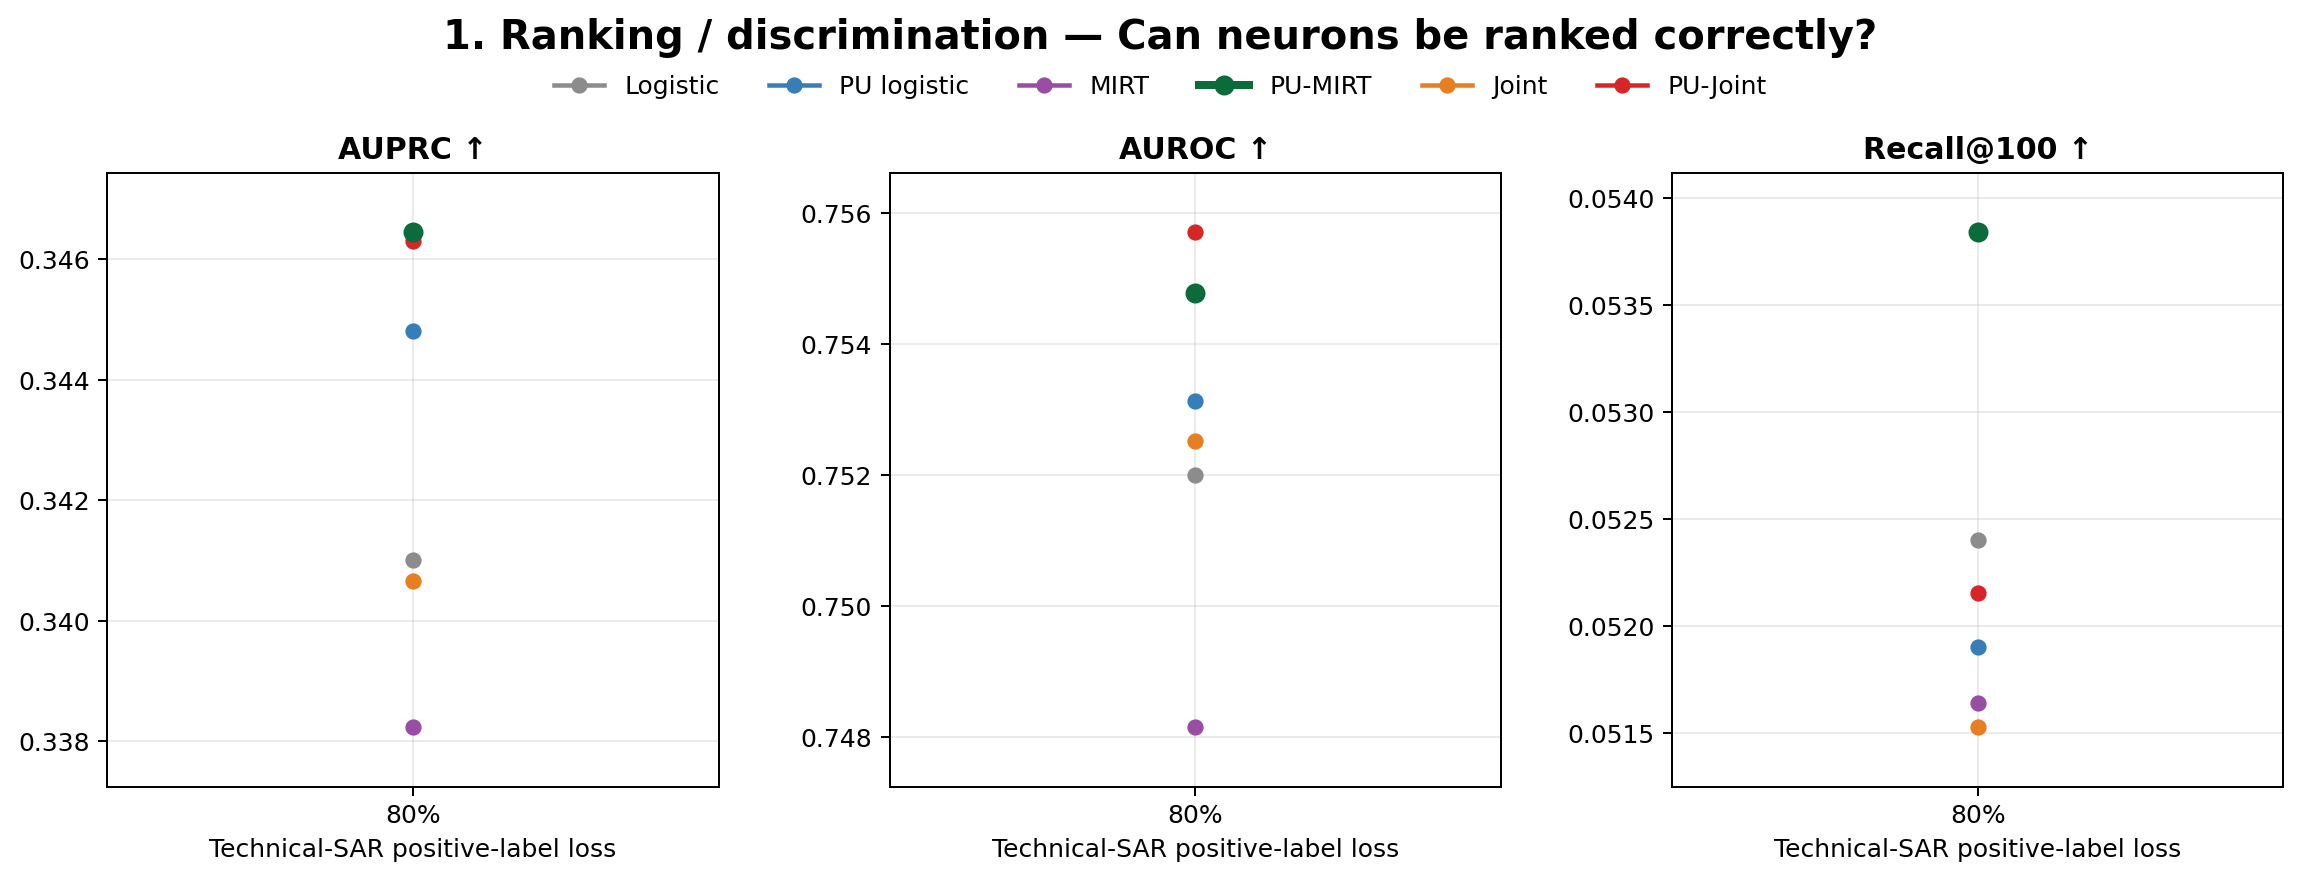

02_latent_probability_quality.png


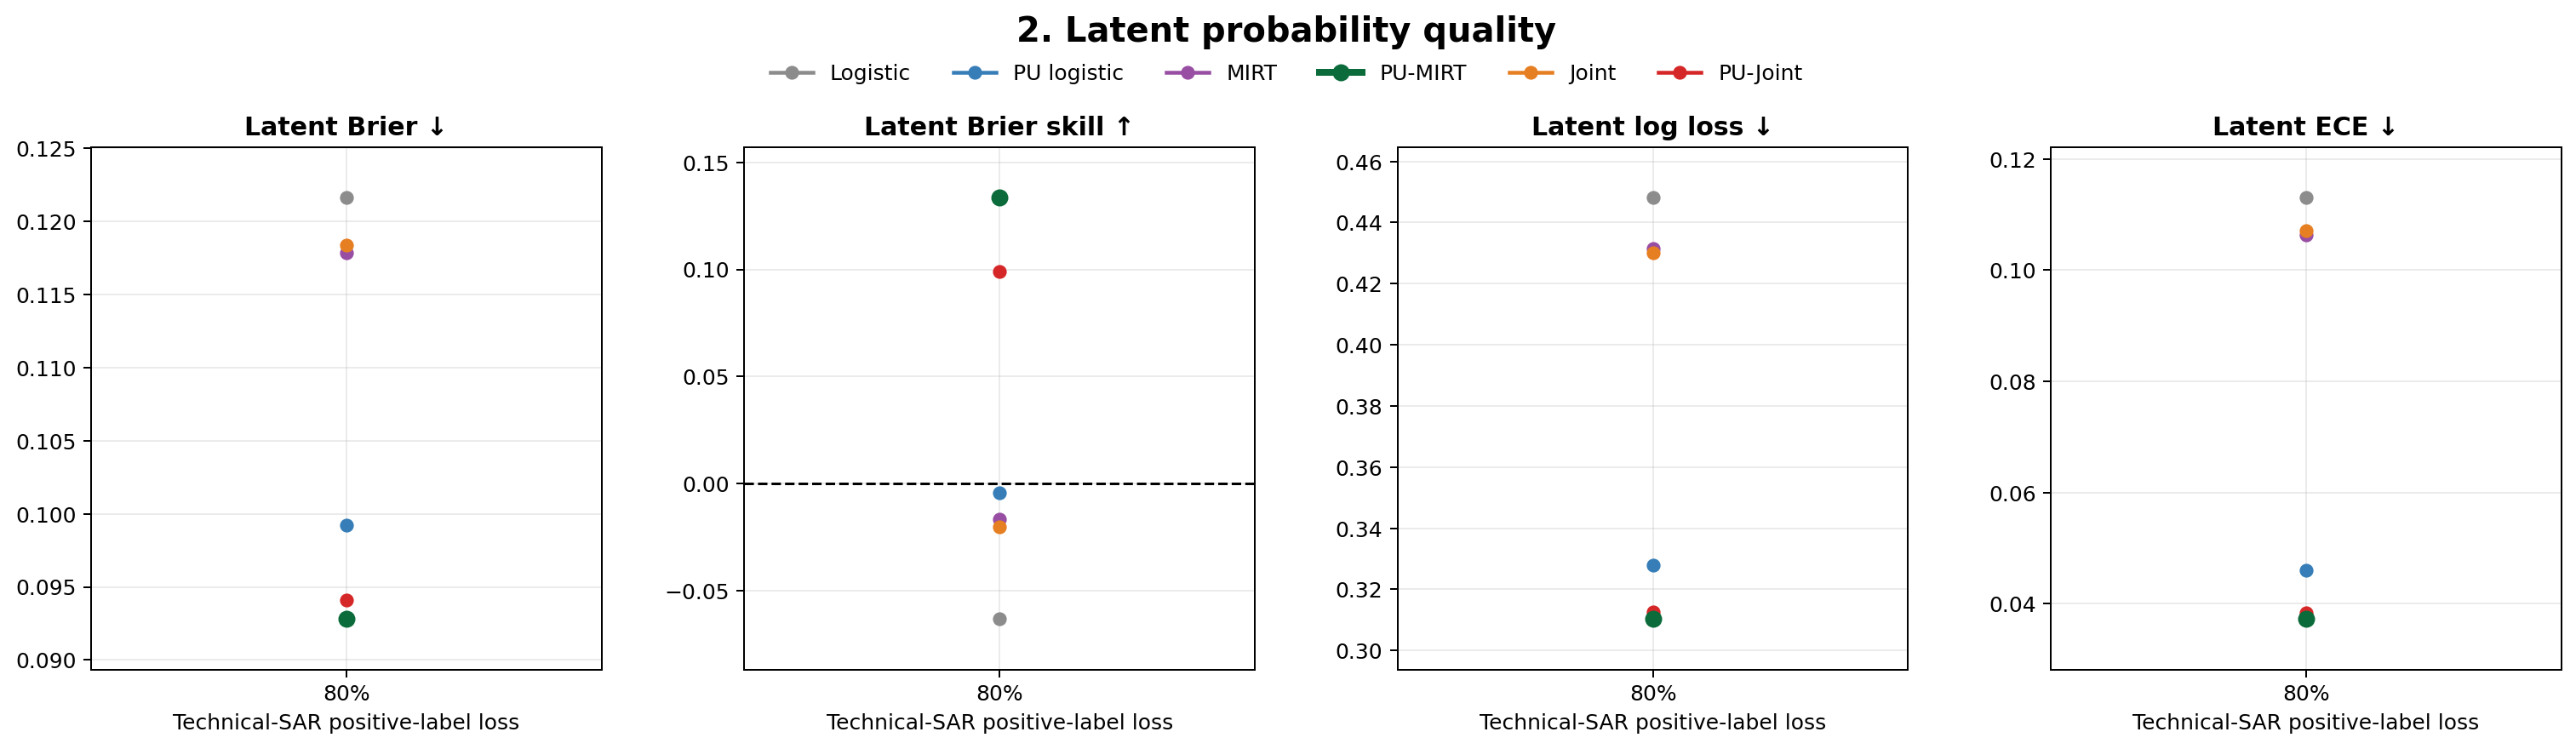

03_prevalence_recovery.png


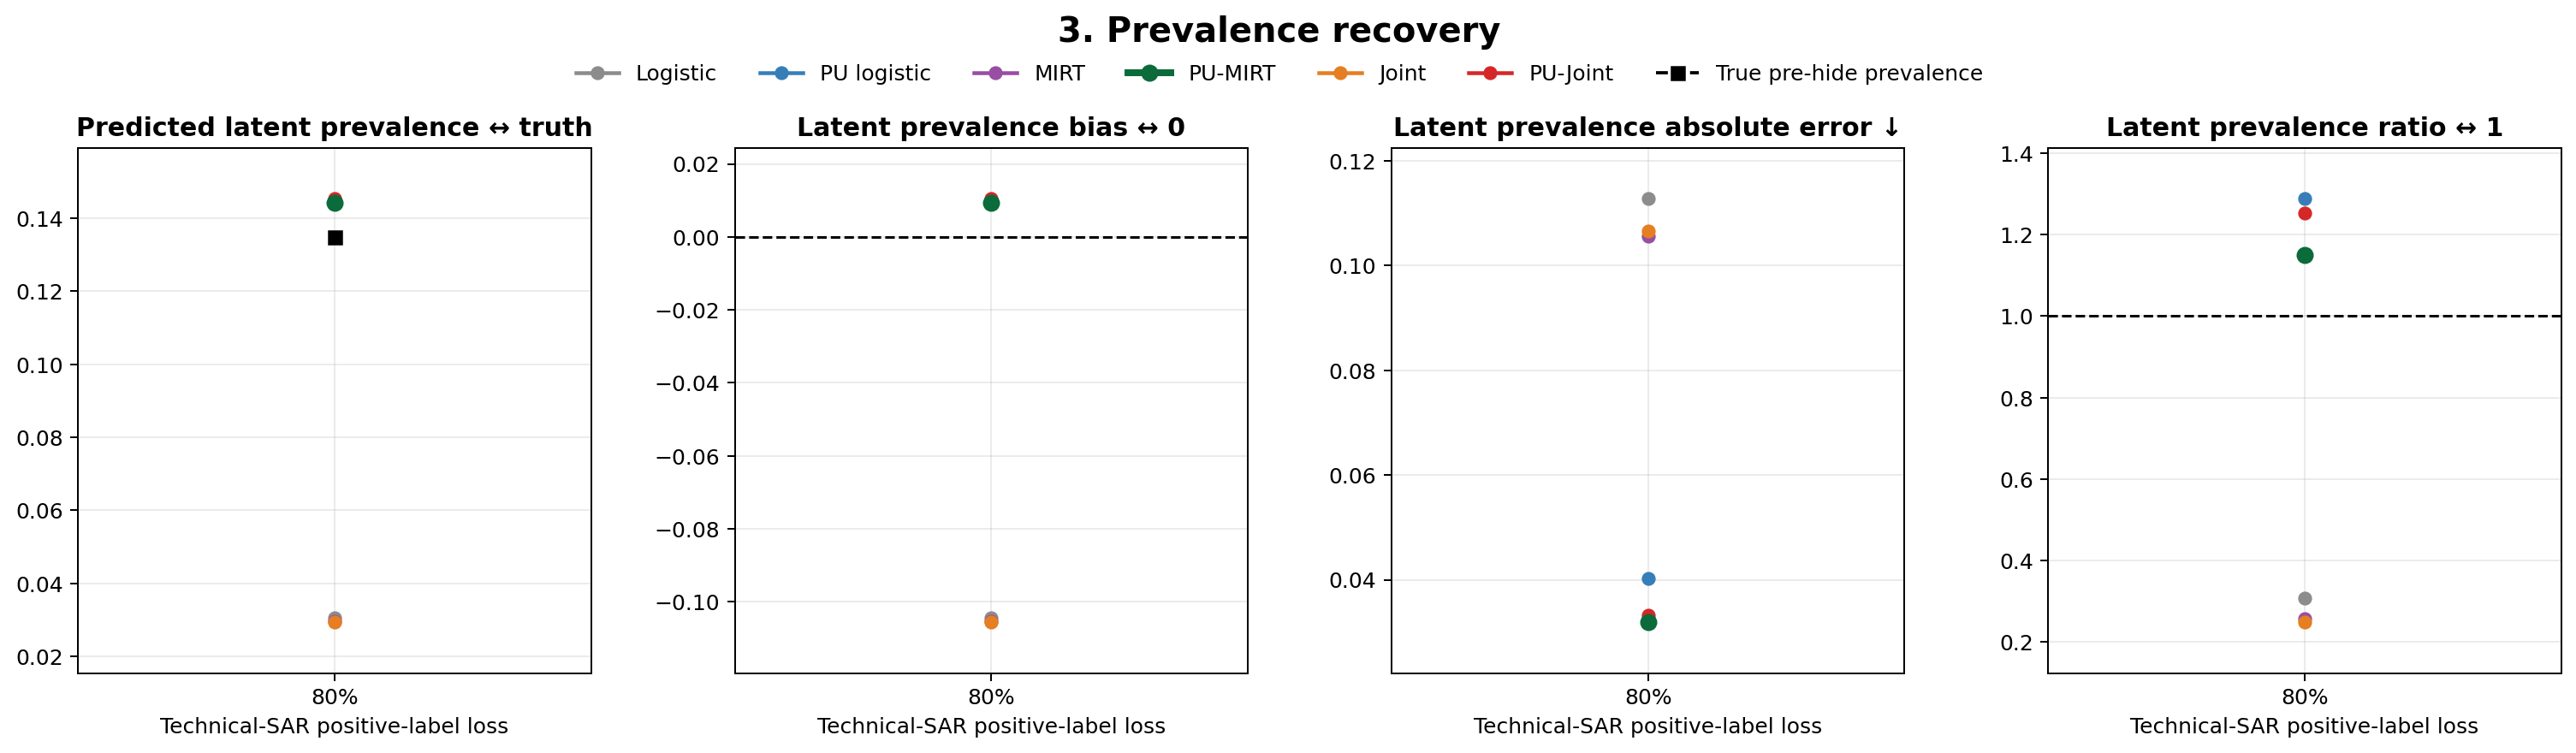

04_detection_probability_quality.png


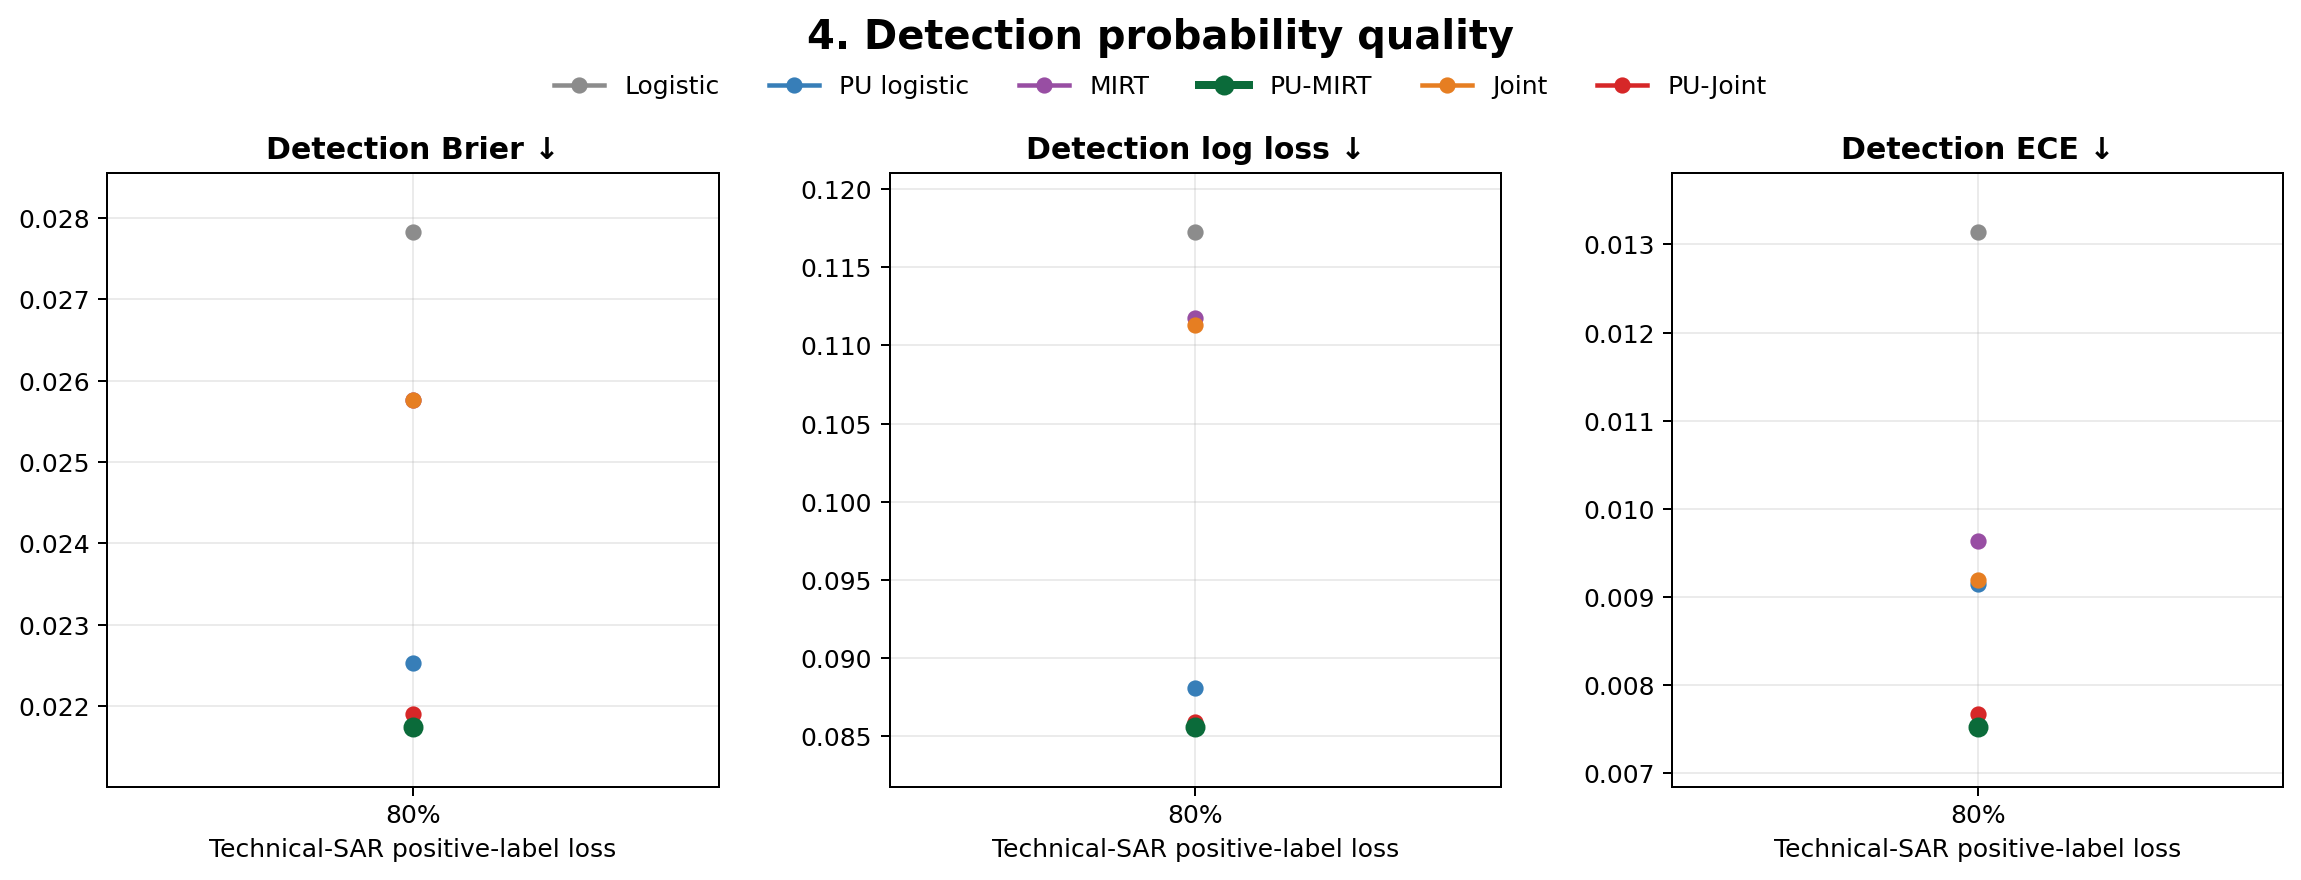

05_hidden_recovery_common_latent.png


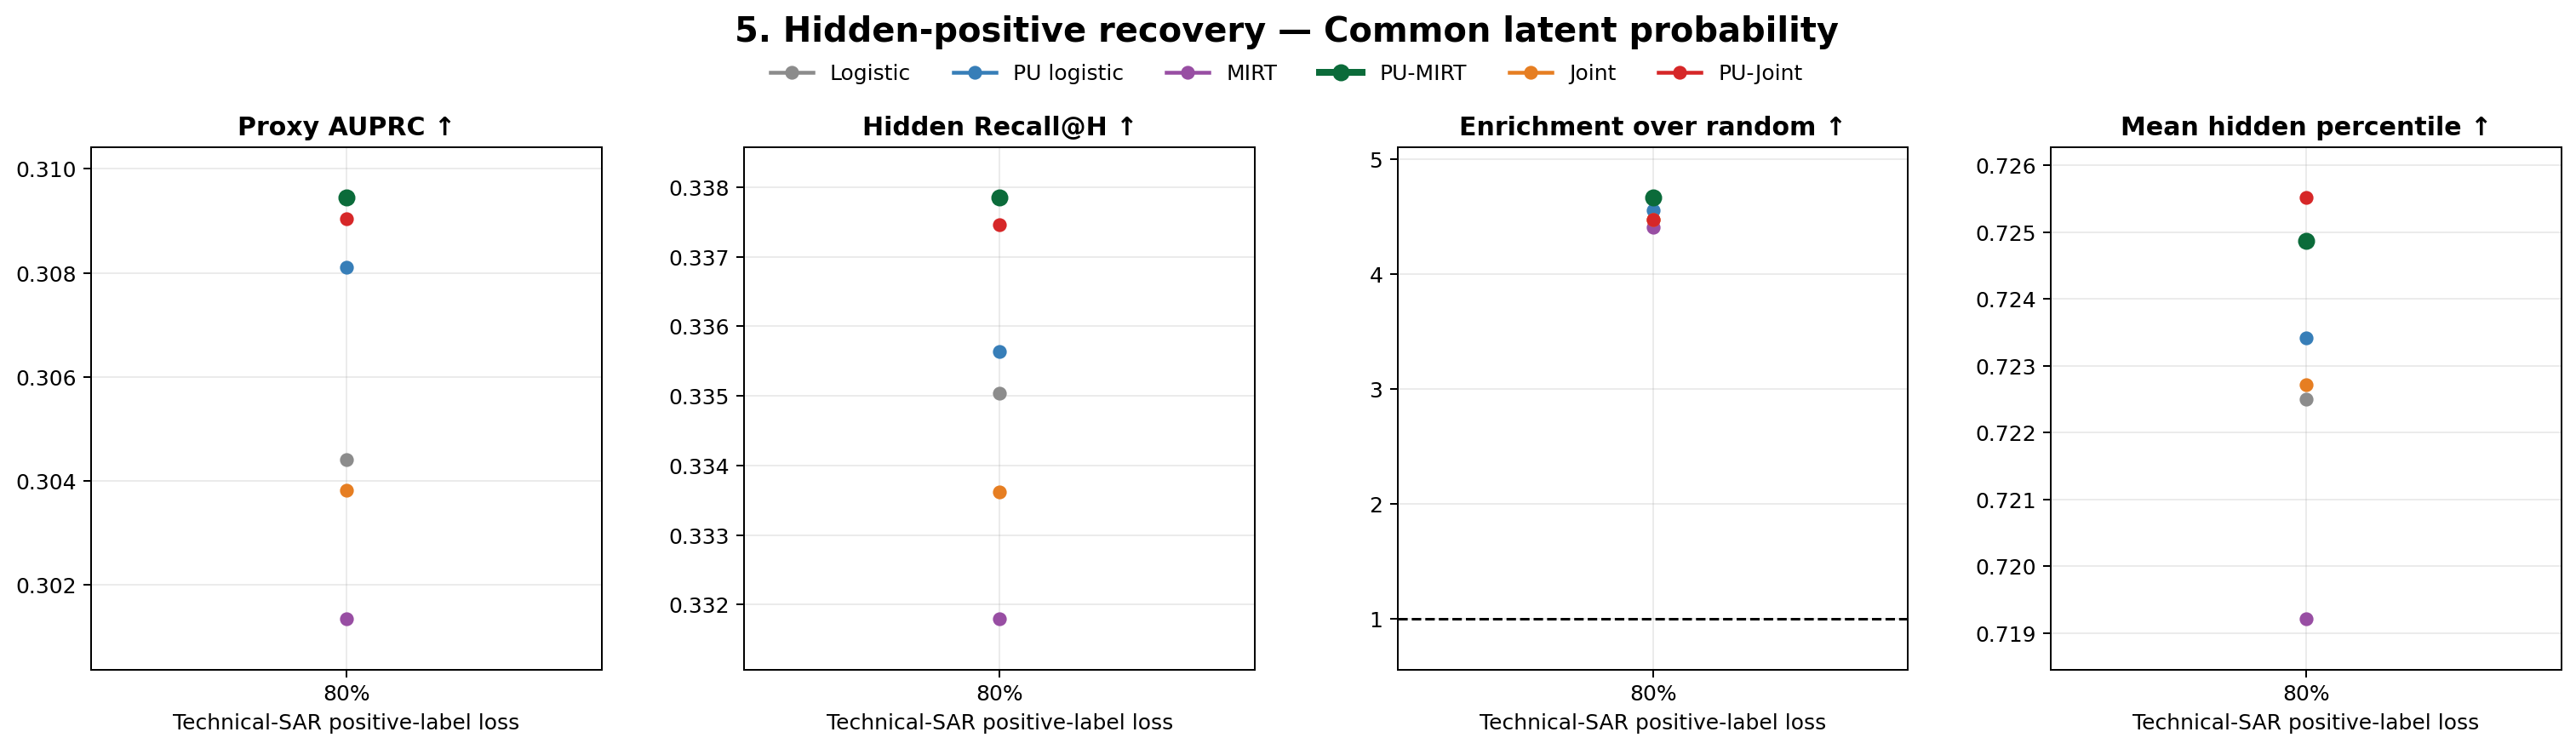

06_hidden_recovery_model_specific.png


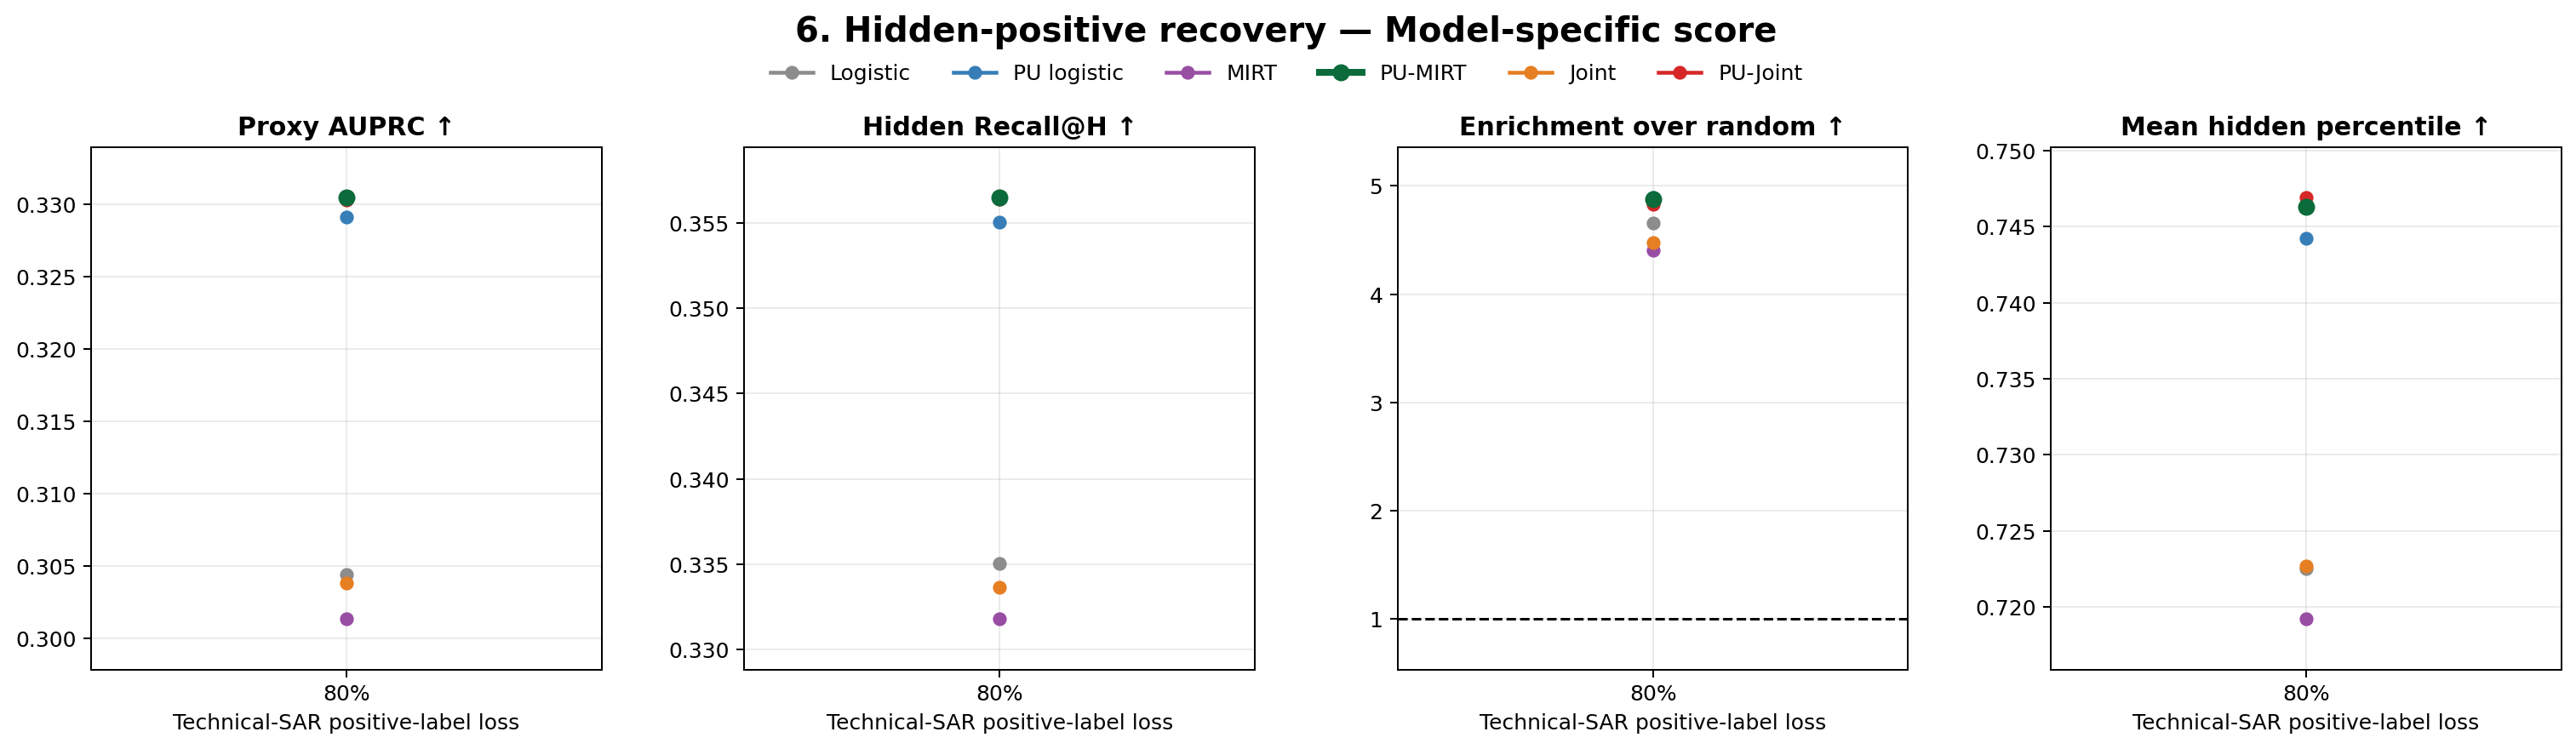

Compact results ZIP: /content/drive/MyDrive/Gene2Wire/results/SPIDER_Technical_SAR_0_20_40_60_80_results.zip
Resume checkpoints remain at: /content/drive/MyDrive/Gene2Wire/results/SPIDER_Technical_SAR_0_20_40_60_80/checkpoints


In [59]:
from IPython.display import Image, display

for figure_path in artifacts.figure_files:
    print(figure_path.name)
    display(Image(filename=str(figure_path)))

archive_path = archive_spider_results(OUTPUT_DIR)
print("Compact results ZIP:", archive_path)
print("Resume checkpoints remain at:", OUTPUT_DIR / "checkpoints")
